# Imports & Helpers

In [1]:
import pandas as pd
import ast
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import sem
import numpy as np
from scipy import stats
from sklearn.metrics import pairwise_distances
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [2]:
from google.colab import drive
drive.mount('/content/drive')

ModuleNotFoundError: No module named 'google'

In [2]:
folder_path = "/content/drive/MyDrive/World Bank/Metanorms/"

## Helpers

In [3]:
# Define choice lists with numeric anchors
EMOTIONS = [
    "Contempt", "Anger", "Disgust",
    "Shame", "Embarrassment", "Guilt",
    "Compassion", "Pride",
    "Other", "No emotion"
]

STRENGTHS = [
    "1 = A little", "2 = Moderate", "3 = A lot", "4 = Extremely"
]

ACTIONS = [
    "1 = Do nothing",
    "2 = Stay away or keep a distance from the actor",
    "3 = Gossip about / discuss with / complain to others informally",
    "4 = Verbal reprimand / verbal confrontation",
    "5 = Physical confrontation", # isn't present in results for GPT
    "6 = Inform the authorities, such as the police",
    "7 = Support the actor",
    "8 = Celebrate / praise"
]

APPROPRIATENESS = [
    "1 = Not at all inappropriate",
    "2 = Somewhat inappropriate",
    "3 = Inappropriate",
    "4 = Very inappropriate",
    "5 = Extremely inappropriate"
]

WRONGNESS = [
    "1 = Not at all wrong",
    "2 = Somewhat wrong",
    "3 = Wrong",
    "4 = Very wrong",
    "5 = Extremely wrong"
]

In [4]:
emotions_keep = [
    "Pride", "Compassion", "Anger", "Contempt",
    "Disgust", "Embarrassment", "Guilt", "Shame"
]

In [5]:
tie_map = {
    "friends": "strong",
    "acquaintances": "weak",
    "strangers": "stranger"
}

In [6]:
# Parse dict-like columns into real Python dicts
dict_cols = [
    "actor_emotions", "actor_emotion_strength",
    "friends_emotions", "friends_emotion_strength",
    "acquaintances_emotions", "acquaintances_emotion_strength",
    "strangers_emotions", "strangers_emotion_strength"
]

In [7]:
def expand_strengths(df, col, actor_label, observer_label=None):
    records = []
    for _, row in df.iterrows():
        if isinstance(row[col], dict):
            for emo, val in row[col].items():
                records.append({
                    "ID": row["ID"],
                    "actor": actor_label,        # friends / acquaintances / strangers
                    "gender": row["gender"],
                    "observer": observer_label,  # LLM name
                    "emotion": emo,
                    "strength": val
                })
    return pd.DataFrame(records)

In [8]:
# Function to return CI bounds
def ci_bounds(x, confidence=0.95):
    x = np.array(x.dropna())  # drop NaNs if any
    if len(x) <= 1:
        return (np.nan, np.nan)
    mean = np.mean(x)
    sem = stats.sem(x)  # standard error of the mean
    h = sem * stats.t.ppf((1 + confidence) / 2., len(x)-1)
    return mean - h, mean + h

In [9]:
def aggregate_emotions(df, group_cols):
    """
    Aggregate emotion data with frequency, mean, std, and 95% CI.

    Parameters:
    -----------
    df : pd.DataFrame
        Long-format dataframe with at least ["emotion", "strength"].
    group_cols : list of str
        Columns to group by (e.g. ["observer", "gender", "emotion"]).

    Returns:
    --------
    pd.DataFrame
        Aggregated dataframe with frequency, avg_strength, std_strength,
        ci_lower, ci_upper.
    """
    agg = (
        df
        .groupby(group_cols)
        .agg(
            frequency=("emotion", "count"),
            avg_strength=("strength", "median"), # mean
            std_strength=("strength", "std"),
            ci=("strength", ci_bounds)
        )
        .reset_index()
    )

    # Split CI into lower/upper columns
    agg[["ci_lower", "ci_upper"]] = pd.DataFrame(agg["ci"].tolist(), index=agg.index)
    agg = agg.drop(columns=["ci"])

    return agg

In [10]:
def aggregate_by_gender(df, tie="strong", col='observer'):
    df_sub = df[df["tie_strength"] == tie]
    agg_df = aggregate_emotions(df_sub, [col, "gender", "emotion"])
    return agg_df

In [11]:
def plot_bubble(df, column, y_column, plt_type, palette="Blues"):
    """
    Create and save a bubble plot for emotions.

    Parameters:
    -----------
    df : pd.DataFrame
        Aggregated dataframe (must include frequency, avg_strength, emotion, y_column, column).
    column : str
        The variable to facet into panels (e.g. "gender", "tie_strength").
    y_column : str
        The variable to plot on the y-axis (e.g. "observer", "MFT").
    plt_type : str
        The variable to specify the plot
    palette : str
        Colormap for bubble colors (default = "Blues").
    """

    # Replace labels for gender if present
    if "gender" in df.columns:
        df["gender"] = df["gender"].replace({"female": "women", "male": "men"})
    if "tie_strength" in df.columns:
        df["tie_strength"] = df["tie_strength"].replace({"strong": "strong tie", "weak": "weak tie"})

    if column == 'gender':
        col_order = ['men', 'women']
    elif column == 'tie_strength':
        col_order = ['strong tie', 'weak tie']

    # Style
    sns.set_style("whitegrid", {"grid.linewidth": 0.5, "grid.alpha": 0.5})

    # Create relplot
    g = sns.relplot(
        data=df,
        x="emotion",
        y=y_column,
        size="frequency",
        hue="avg_strength",
        col=column,
        col_order=col_order,
        kind="scatter",
        height=8,
        aspect=0.8,
        sizes=(40, 400),
        palette=palette,
        alpha=0.7,
        facet_kws={'sharey': True, 'sharex': False}
    )

    # Style each subplot
    for ax in g.axes.flat:
        ax.grid(True, alpha=0.4, linestyle='-', linewidth=0.3, color='#E0E0E0')
        ax.set_facecolor('#FAFAFA')

        # Bubble edges
        for collection in ax.collections:
            collection.set_edgecolors('white')
            collection.set_linewidth(0.8)

        # Axis styling
        ax.tick_params(axis='x', rotation=90, labelsize=9, pad=2)
        ax.tick_params(axis='y', labelsize=9, pad=2)

        # Remove spines
        for spine in ax.spines.values():
            spine.set_visible(False)

    # Titles & labels
    g.set_titles("{col_name}", size=12, weight='bold', pad=20)
    g.set_axis_labels("", "")

    # Remove legends
    if g._legend:
        g._legend.remove()
    for ax in g.axes.flat:
        legend = ax.get_legend()
        if legend:
            legend.remove()

    # ---- Custom colorbar ----
    norm = plt.Normalize(vmin=1, vmax=5)
    sm = plt.cm.ScalarMappable(cmap=palette, norm=norm)
    sm.set_array([])
    g.fig.subplots_adjust(right=0.88)
    cbar_ax = g.fig.add_axes([0.9, 0.15, 0.02, 0.75])
    cbar = g.fig.colorbar(sm, cax=cbar_ax)
    cbar.set_label('Strength (1–5)', rotation=270, labelpad=20, fontsize=10)
    cbar.set_ticks([1, 2, 3, 4, 5])
    cbar.ax.tick_params(labelsize=9)

    # Layout
    plt.tight_layout()
    plt.subplots_adjust(right=0.88, top=0.9)
    g.fig.patch.set_facecolor('white')

    # Save figure
    filename = f"{plt_type}_{y_column}_emotion_{column}.png"
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()

# Load Data

In [12]:
folder_path_data="../data/"
folder_path_output_closed = "../output/closed-source"
folder_path_output_open = "../output/open-source"

In [14]:
# Load CSV file
df = pd.read_csv(folder_path_data+"rotexamples_07072025.csv")
df_gender = pd.read_csv(folder_path_data+"rotexamples_07072025_genders.csv")

In [15]:
df_gpt_41 = pd.read_csv(folder_path_output_closed+"/gpt_4.1_responses.csv")
df_gpt_5 = pd.read_csv(folder_path_output_closed+"/gpt_5_responses.csv")
df_gpt = pd.read_csv(folder_path_output_closed+"/gpt_4.1_responses.csv")
df_claude = pd.read_csv(folder_path_output_closed+"/claude_responses.csv")
df_gemini = pd.read_csv(folder_path_output_closed+"/gemini_responses.csv")

df_gpt_oss = pd.read_csv(folder_path_output_open+"/gpt_oss_responses.csv")
df_gemma = pd.read_csv(folder_path_output_open+"/gemma_responses.csv")
df_llama = pd.read_csv(folder_path_output_open+"/llama_responses.csv")

In [16]:
df_gpt_41_gender = pd.read_csv(folder_path_output_closed+"/Gender/gpt_4.1_responses.csv")
df_gpt_5_gender = pd.read_csv(folder_path_output_closed+"/Gender/gpt_5_responses.csv")
df_gpt_gender = pd.read_csv(folder_path_output_closed+"/Gender/gpt_4.1_responses.csv")
df_claude_gender = pd.read_csv(folder_path_output_closed+"/Gender/claude_responses.csv")
df_gemini_gender = pd.read_csv(folder_path_output_closed+"/Gender/gemini_responses.csv")

df_gpt_oss_gender = pd.read_csv(folder_path_output_open+"/Gender/gpt_oss_responses.csv")
df_gemma_gender = pd.read_csv(folder_path_output_open+"/Gender/gemma_responses.csv")
df_llama_gender = pd.read_csv(folder_path_output_open+"/Gender/llama_responses.csv")

In [17]:
for col in dict_cols:
    df_gpt_41[col] = df_gpt_41[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) and x.strip().startswith("{") else x)
    df_gpt_5[col] = df_gpt_5[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) and x.strip().startswith("{") else x)
    df_gpt[col] = df_gpt[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) and x.strip().startswith("{") else x)
    df_claude[col] = df_claude[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) and x.strip().startswith("{") else x)
    df_gemini[col] = df_gemini[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) and x.strip().startswith("{") else x)
    df_gemma[col] = df_gemma[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) and x.strip().startswith("{") else x)
    df_llama[col] = df_llama[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) and x.strip().startswith("{") else x)
    df_gpt_oss[col] = df_gpt_oss[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) and x.strip().startswith("{") else x)

    df_gpt_41_gender[col] = df_gpt_41_gender[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) and x.strip().startswith("{") else x)
    df_gpt_5_gender[col] = df_gpt_5_gender[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) and x.strip().startswith("{") else x)
    df_gpt_gender[col] = df_gpt_gender[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) and x.strip().startswith("{") else x)
    df_claude_gender[col] = df_claude_gender[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) and x.strip().startswith("{") else x)
    df_gemini_gender[col] = df_gemini_gender[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) and x.strip().startswith("{") else x)
    df_gemma_gender[col] = df_gemma_gender[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) and x.strip().startswith("{") else x)
    df_llama_gender[col] = df_llama_gender[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) and x.strip().startswith("{") else x)
    df_gpt_oss_gender[col] = df_gpt_oss_gender[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) and x.strip().startswith("{") else x)

In [18]:
# Select only the relevant metadata columns
meta = df[["ID", "MFT", "rot-agree", "action-agree", "action-pressure", "action-hypothetical"]]

# Merge each model dataframe with the metadata
df_gpt_41  = df_gpt_41.merge(meta, on="ID", how="inner")
df_gpt_5   = df_gpt_5.merge(meta, on="ID", how="inner")
df_gemma   = df_gemma.merge(meta, on="ID", how="inner")
df_claude  = df_claude.merge(meta, on="ID", how="inner")
df_gemini  = df_gemini.merge(meta, on="ID", how="inner")
df_gpt_oss = df_gpt_oss.merge(meta, on="ID", how="inner")
df_llama   = df_llama.merge(meta, on="ID", how="inner")

df_gpt_41_gender  = df_gpt_41_gender.merge(meta, on="ID", how="inner")
df_gpt_5_gender   = df_gpt_5_gender.merge(meta, on="ID", how="inner")
df_gemma_gender   = df_gemma_gender.merge(meta, on="ID", how="inner")
df_claude_gender  = df_claude_gender.merge(meta, on="ID", how="inner")
df_gemini_gender  = df_gemini_gender.merge(meta, on="ID", how="inner")
df_gpt_oss_gender = df_gpt_oss_gender.merge(meta, on="ID", how="inner")
df_llama_gender   = df_llama_gender.merge(meta, on="ID", how="inner")

In [19]:
df_gpt_41.head()

,ID,stimuli,actor,gender,actor_emotions,actor_emotion_strength,friends_emotions,friends_emotion_strength,friends_reaction,friends_reaction_should,...,strangers_emotion_strength,strangers_reaction,strangers_reaction_should,norm_inappropriateness,norm_wrongness,MFT,rot-agree,action-agree,action-pressure,action-hypothetical
0,1,William did not tell someone's girlfriend that...,William,male,"{'emotions': ['Guilt'], 'other_emotions': [], ...",{'Guilt': 2},"{'emotions': ['Contempt', 'Anger'], 'other_emo...","{'Contempt': 2, 'Anger': 2}",3,3,...,{'Contempt': 2},3,3,3,3,care-harm,4,4,2,explicit-no
1,1,Maria did not tell someone's girlfriend that h...,Maria,female,"{'emotions': ['Guilt', 'Compassion'], 'other_e...","{'Guilt': 2, 'Compassion': 2}","{'emotions': ['Guilt', 'Compassion'], 'other_e...","{'Guilt': 2, 'Compassion': 2}",1,1,...,"{'Guilt': 1, 'Compassion': 1}",1,1,2,2,care-harm,4,4,2,explicit-no
2,2,John rarely talks to his elderly roommates and...,John,male,"{'emotions': ['Shame', 'Guilt'], 'other_emotio...","{'Shame': 2, 'Guilt': 2}","{'emotions': ['Shame', 'Embarrassment', 'Guilt...","{'Shame': 2, 'Embarrassment': 2, 'Guilt': 1, '...",3,4,...,{'Contempt': 1},1,1,2,2,care-harm,3,3,1,explicit-no
3,2,Mary rarely talks to her elderly roommates and...,Mary,female,"{'emotions': ['Shame', 'Guilt'], 'other_emotio...","{'Shame': 2, 'Guilt': 2}","{'emotions': ['Contempt', 'Anger', 'Disgust', ...","{'Contempt': 2, 'Anger': 1, 'Disgust': 1, 'Sha...",3,3,...,{'Contempt': 1},2,2,3,3,care-harm,3,3,1,explicit-no
4,3,Robert stayed up until 5 am because he assumed...,Robert,male,"{'emotions': [], 'other_emotions': [], 'no_emo...",NaN,"{'emotions': [], 'other_emotions': [], 'no_emo...",NaN,1,1,...,NaN,1,1,1,1,care-harm,3,2,0,hypothetical


# LLM Plots

## Self

In [21]:
expanded_dfs = []

for model_name, df in {
    "GPT-4.1": df_gpt_41,
    "GPT-5": df_gpt_5,
    "Gemma": df_gemma,
    "Claude": df_claude,
    "Gemini": df_gemini,
    "GPT-OSS": df_gpt_oss,
    "LLaMA": df_llama
}.items():
    expanded = expand_strengths(df, col="actor_emotion_strength", actor_label='self', observer_label=model_name)
    expanded_dfs.append(expanded)

df_all = pd.concat(expanded_dfs, ignore_index=True)

# Keep only selected emotions
df_all = df_all[df_all["emotion"].isin(emotions_keep)].reset_index(drop=True)
df_all.head()

,ID,actor,gender,observer,emotion,strength
0,1,self,male,GPT-4.1,Guilt,2.0
1,1,self,female,GPT-4.1,Guilt,2.0
2,1,self,female,GPT-4.1,Compassion,2.0
3,2,self,male,GPT-4.1,Shame,2.0
4,2,self,male,GPT-4.1,Guilt,2.0


In [ ]:
agg_df = aggregate_emotions(df_all, ["observer", "gender", "emotion"])
agg_df

,observer,gender,emotion,frequency,avg_strength,std_strength,ci_lower,ci_upper
0,Claude,female,Anger,50,2.700000,0.505076,2.556459,2.843541
1,Claude,female,Compassion,6,2.833333,0.408248,2.404903,3.261764
2,Claude,female,Contempt,2,2.500000,0.707107,-3.853102,8.853102
3,Claude,female,Disgust,15,2.866667,0.833809,2.404918,3.328415
4,Claude,female,Embarrassment,96,2.406250,0.608330,2.282991,2.529509
...,...,...,...,...,...,...,...,...
107,LLaMA,male,Disgust,102,3.401961,0.549704,3.293989,3.509933
108,LLaMA,male,Embarrassment,84,2.761905,0.505846,2.652129,2.871680
109,LLaMA,male,Guilt,272,2.922794,0.361315,2.879663,2.965926
110,LLaMA,male,Pride,27,2.925926,0.474417,2.738253,3.113599


/tmp/ipython-input-3608932637.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


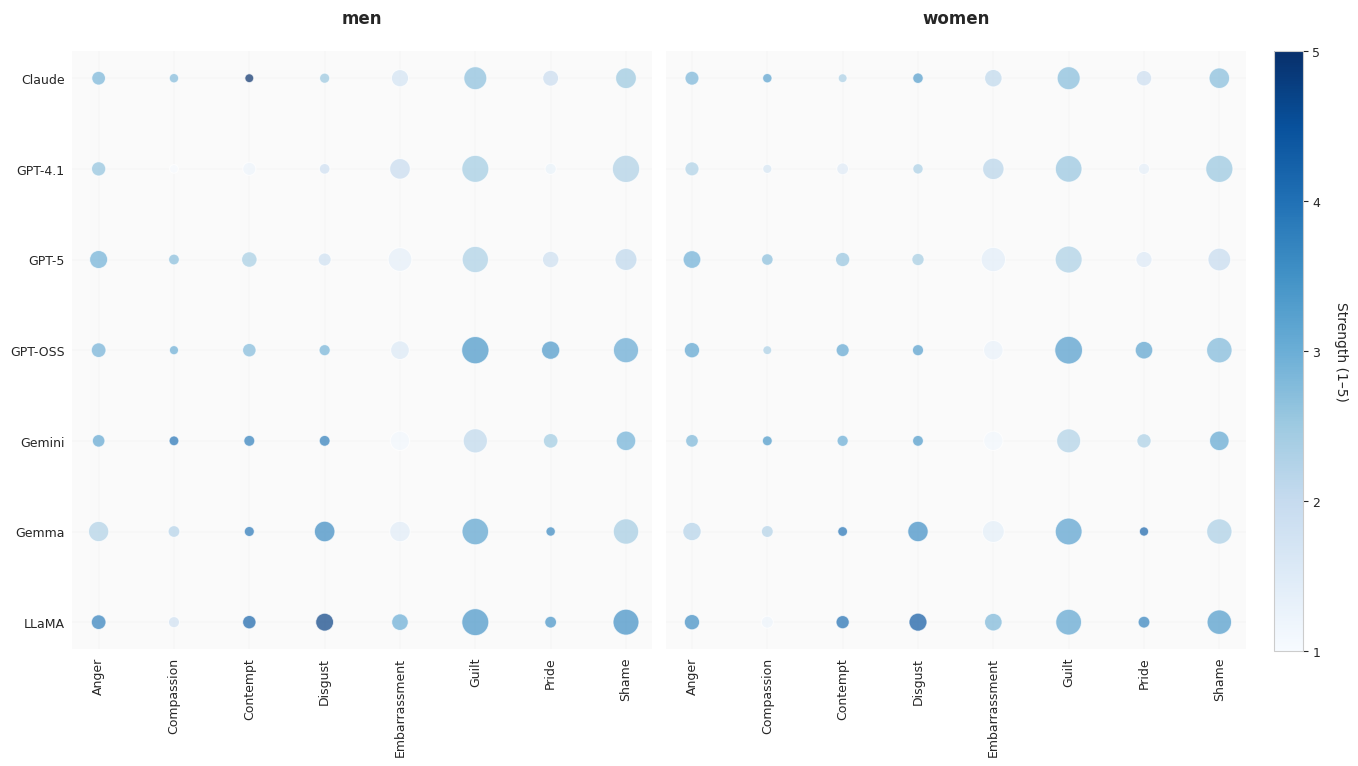

In [ ]:
plot_bubble(agg_df, "gender", "observer", plt_type='llm_self', palette="Blues")

### Statistical Tests

In [ ]:
results = []

# Group by emotion only (ignore gender)
for emotion, subset in df_all.groupby("emotion"):
    groups = [group["strength"].dropna().values
              for _, group in subset.groupby("observer")]

    if len(groups) > 1:
        # Parametric test (ANOVA)
        f_stat, p_val_anova = stats.f_oneway(*groups)

        # Non-parametric test (Kruskal-Wallis)
        h_stat, p_val_kruskal = stats.kruskal(*groups)

        results.append({
            "emotion": emotion,
            "anova_f": f_stat,
            "anova_p": p_val_anova,
            "kruskal_h": h_stat,
            "kruskal_p": p_val_kruskal
        })

stats_df = pd.DataFrame(results)
stats_df


,emotion,anova_f,anova_p,kruskal_h,kruskal_p
0,Anger,14.395741,8.889188e-16,82.124817,1.299649e-15
1,Compassion,6.502255,3.157728e-06,30.710635,2.878584e-05
2,Contempt,24.784227,3.708492e-25,120.010755,1.621133e-23
3,Disgust,24.369349,2.961664e-26,122.499264,4.863831e-24
4,Embarrassment,34.926039,3.189664e-40,204.669234,1.923724e-41
5,Guilt,39.271915,1.923650e-46,241.294447,2.970163e-49
6,Pride,34.678389,6.844593e-37,178.382100,7.484614e-36
7,Shame,34.257754,3.685231e-40,230.613970,5.662738e-47


For all 8 emotions, the LLMs don’t behave the same in terms of emotion strength

In [ ]:
subset = df_all[df_all["emotion"] == "Disgust"]
tukey = pairwise_tukeyhsd(subset["strength"], subset["observer"], alpha=0.05)
print(tukey.summary())

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1  group2 meandiff p-adj   lower  upper  reject
-----------------------------------------------------
 Claude GPT-4.1  -0.3407 0.4371 -0.8531 0.1716  False
 Claude   GPT-5  -0.3323 0.2703  -0.769 0.1044  False
 Claude GPT-OSS    0.045    1.0 -0.4315 0.5214  False
 Claude  Gemini   0.2315 0.8062 -0.2603 0.7232  False
 Claude   Gemma   0.2314 0.5758 -0.1574 0.6202  False
 Claude   LLaMA   0.5942 0.0002  0.1989 0.9895   True
GPT-4.1   GPT-5   0.0085    1.0 -0.4121 0.4291  False
GPT-4.1 GPT-OSS   0.3857 0.1718  -0.076 0.8474  False
GPT-4.1  Gemini   0.5722 0.0077  0.0947 1.0497   True
GPT-4.1   Gemma   0.5721 0.0001  0.2015 0.9427   True
GPT-4.1   LLaMA    0.935    0.0  0.5575 1.3124   True
  GPT-5 GPT-OSS   0.3773 0.0486  0.0013 0.7533   True
  GPT-5  Gemini   0.5638 0.0006  0.1686  0.959   True
  GPT-5   Gemma   0.5637    0.0  0.3077 0.8197   True
  GPT-5   LLaMA   0.9265    0.0  0.6607 1.1923   True
GPT-OSS  Gemini   0.1865 0.8

In [ ]:
# Pivot to model × emotion matrix (average strength)
pivot = agg_df.pivot_table(
    index="observer",
    columns="emotion",
    values="avg_strength"
)

pivot = pivot.fillna(0)
dist_matrix = pairwise_distances(pivot.values, metric="euclidean")
dist_df = pd.DataFrame(dist_matrix, index=pivot.index, columns=pivot.index)

avg_dist = dist_df.mean(axis=1)  # mean distance per model
representative = avg_dist.idxmin()  # the most central model
representative

'Claude'

## Others

In [ ]:
expanded_dfs = []

for model_name, df in {
    "GPT-4.1": df_gpt_41,
    "GPT-5": df_gpt_5,
    "Gemma": df_gemma,
    "Claude": df_claude,
    "Gemini": df_gemini,
    "GPT-OSS": df_gpt_oss,
    "LLaMA": df_llama
}.items():
    expanded_dfs.append(expand_strengths(df, "friends_emotion_strength", "friends", model_name))
    expanded_dfs.append(expand_strengths(df, "acquaintances_emotion_strength", "acquaintances", model_name))
    expanded_dfs.append(expand_strengths(df, "strangers_emotion_strength", "strangers", model_name))

df_all = pd.concat(expanded_dfs, ignore_index=True)
df_all["tie_strength"] = df_all["actor"].map(tie_map)
df_all = df_all[df_all["emotion"].isin(emotions_keep)].reset_index(drop=True)
df_all

,ID,actor,gender,observer,emotion,strength,tie_strength
0,1,friends,male,GPT-4.1,Contempt,2.0,strong
1,1,friends,male,GPT-4.1,Anger,2.0,strong
2,1,friends,female,GPT-4.1,Guilt,2.0,strong
3,1,friends,female,GPT-4.1,Compassion,2.0,strong
4,2,friends,male,GPT-4.1,Shame,2.0,strong
...,...,...,...,...,...,...,...
34957,450,strangers,female,LLaMA,Contempt,2.0,weak
34958,450,strangers,female,LLaMA,Anger,2.0,weak
34959,450,strangers,female,LLaMA,Disgust,2.0,weak
34960,451,strangers,male,LLaMA,Disgust,3.0,weak


In [ ]:
agg_ties = aggregate_emotions(df_all, ["observer", "tie_strength", "emotion"])
agg_ties

,observer,tie_strength,emotion,frequency,avg_strength,std_strength,ci_lower,ci_upper
0,Claude,strong,Anger,388,2.902062,0.610584,2.841117,2.963007
1,Claude,strong,Compassion,150,2.553333,0.640225,2.450039,2.656628
2,Claude,strong,Contempt,45,2.555556,0.724743,2.337819,2.773292
3,Claude,strong,Disgust,442,2.644796,0.736531,2.575944,2.713649
4,Claude,strong,Embarrassment,321,2.236760,0.500019,2.181853,2.291667
...,...,...,...,...,...,...,...,...
101,LLaMA,weak,Disgust,1082,2.270795,0.581600,2.236102,2.305488
102,LLaMA,weak,Embarrassment,52,2.250000,0.589948,2.085757,2.414243
103,LLaMA,weak,Guilt,5,2.000000,0.000000,2.000000,2.000000
104,LLaMA,weak,Pride,28,2.892857,0.314970,2.770724,3.014990


/tmp/ipython-input-3608932637.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


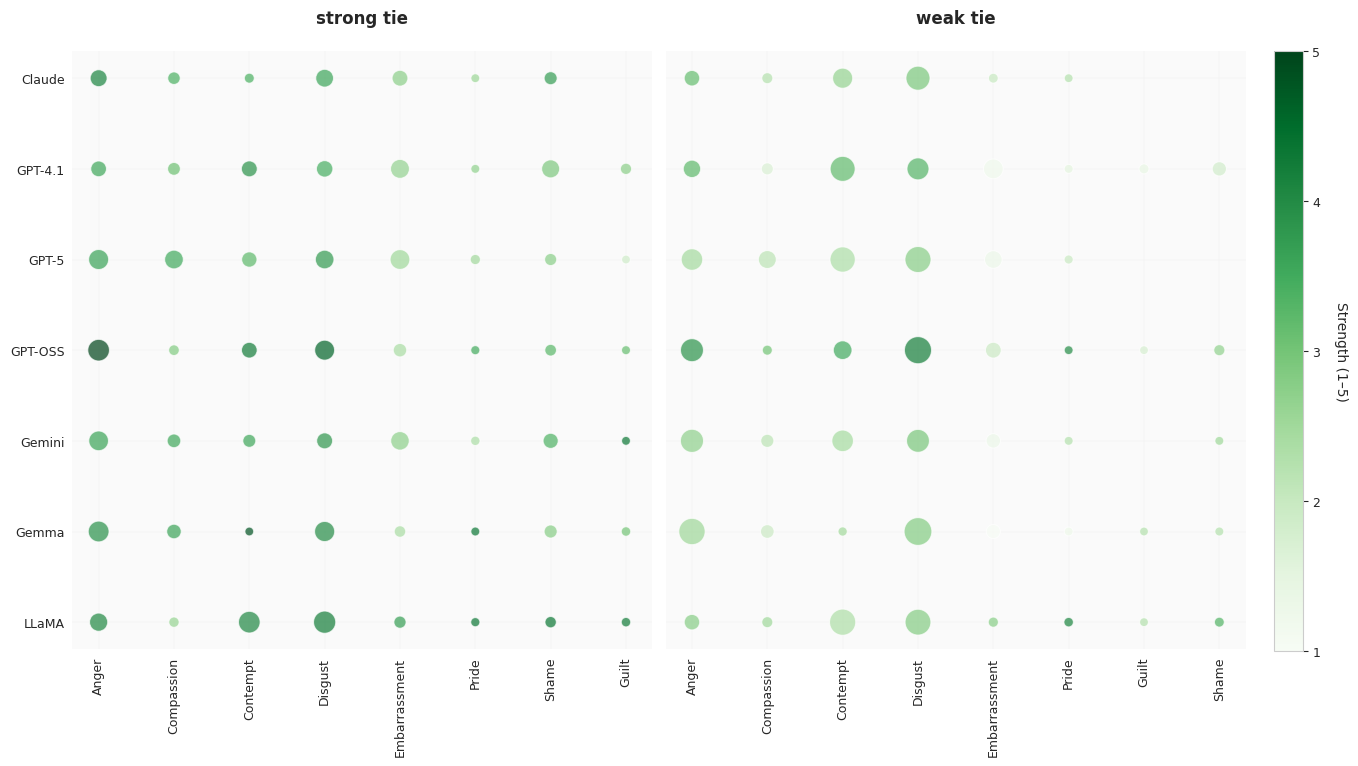

In [ ]:
plot_bubble(agg_ties, "tie_strength", "observer", plt_type='llm_others', palette="Greens")

### Statistical Tests

In [ ]:
results = []

# Group by emotion only (ignore gender)
for emotion, subset in df_all.groupby("emotion"):
    groups = [group["strength"].dropna().values
              for _, group in subset.groupby("observer")]

    if len(groups) > 1:
        # Parametric test (ANOVA)
        f_stat, p_val_anova = stats.f_oneway(*groups)

        # Non-parametric test (Kruskal-Wallis)
        h_stat, p_val_kruskal = stats.kruskal(*groups)

        results.append({
            "emotion": emotion,
            "anova_f": f_stat,
            "anova_p": p_val_anova,
            "kruskal_h": h_stat,
            "kruskal_p": p_val_kruskal
        })

stats_df = pd.DataFrame(results)
stats_df

,emotion,anova_f,anova_p,kruskal_h,kruskal_p
0,Anger,175.487167,7.165523e-211,913.946305,3.628554e-194
1,Compassion,4.713589,8.807488e-05,29.383322,5.147079e-05
2,Contempt,93.722861,1.458670e-113,514.201654,7.329677e-108
3,Disgust,141.151229,7.584067e-173,805.988924,7.824425e-171
4,Embarrassment,66.944171,7.986594e-80,366.547298,4.316927e-76
5,Guilt,12.683101,7.281011e-11,51.607727,6.492446e-10
6,Pride,14.518520,8.043956e-14,73.033529,9.743160e-14
7,Shame,41.907199,4.628715e-48,251.454955,2.004421e-51


In [ ]:
subset = df_all[df_all["emotion"] == "Disgust"]
tukey = pairwise_tukeyhsd(subset["strength"], subset["observer"], alpha=0.05)
print(tukey.summary())

 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2 meandiff p-adj   lower   upper  reject
------------------------------------------------------
 Claude GPT-4.1    0.106 0.0089  0.0163  0.1957   True
 Claude   GPT-5  -0.0259 0.9672 -0.1076  0.0558  False
 Claude GPT-OSS   0.5928    0.0  0.5132  0.6724   True
 Claude  Gemini   0.0282 0.9663 -0.0605  0.1169  False
 Claude   Gemma   0.0295 0.9272 -0.0494  0.1084  False
 Claude   LLaMA   0.1285    0.0  0.0493  0.2076   True
GPT-4.1   GPT-5  -0.1319 0.0001 -0.2185 -0.0452   True
GPT-4.1 GPT-OSS   0.4868    0.0  0.4021  0.5714   True
GPT-4.1  Gemini  -0.0778 0.1747  -0.171  0.0155  False
GPT-4.1   Gemma  -0.0765 0.1021 -0.1605  0.0075  False
GPT-4.1   LLaMA   0.0225 0.9863 -0.0618  0.1067  False
  GPT-5 GPT-OSS   0.6186    0.0  0.5425  0.6948   True
  GPT-5  Gemini   0.0541 0.5048 -0.0315  0.1397  False
  GPT-5   Gemma   0.0554 0.3139   -0.02  0.1308  False
  GPT-5   LLaMA   0.1543    0.0  0.0787    0.23   True
GPT-OSS  G

In [ ]:
# Pivot to model × emotion matrix (average strength)
pivot = agg_df.pivot_table(
    index="observer",
    columns="emotion",
    values="avg_strength"
)

pivot = pivot.fillna(0)  # just in case
dist_matrix = pairwise_distances(pivot.values, metric="euclidean")
dist_df = pd.DataFrame(dist_matrix, index=pivot.index, columns=pivot.index)

avg_dist = dist_df.mean(axis=1)  # mean distance per model
representative = avg_dist.idxmin()  # the most central model
representative

'Claude'

### Gender Differences

In [ ]:
agg_gender_strong = aggregate_by_gender(df_all, tie="strong")
agg_gender_weak = aggregate_by_gender(df_all, tie="weak")

/tmp/ipython-input-3608932637.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


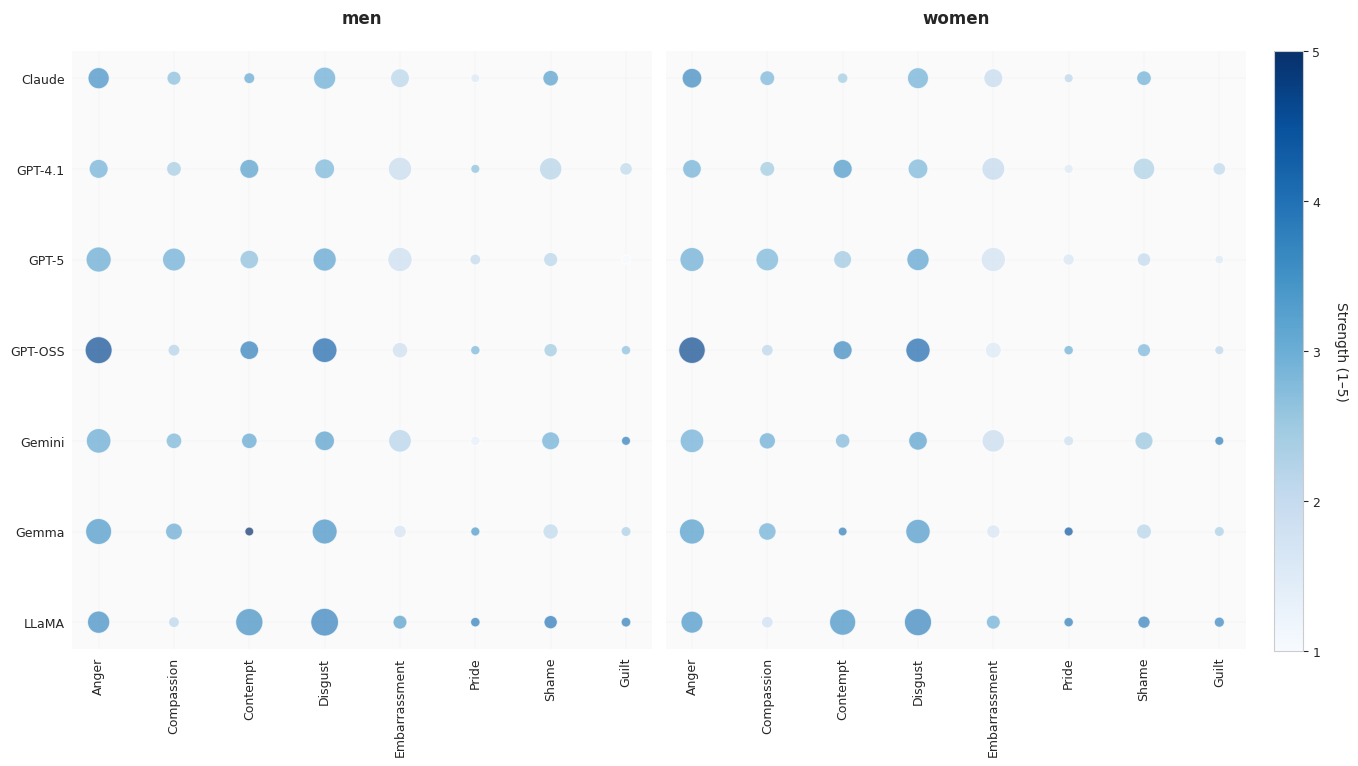

In [ ]:
plot_bubble(agg_gender_strong, "gender", "observer", plt_type='llm_strong_tie', palette="Blues")

/tmp/ipython-input-3608932637.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


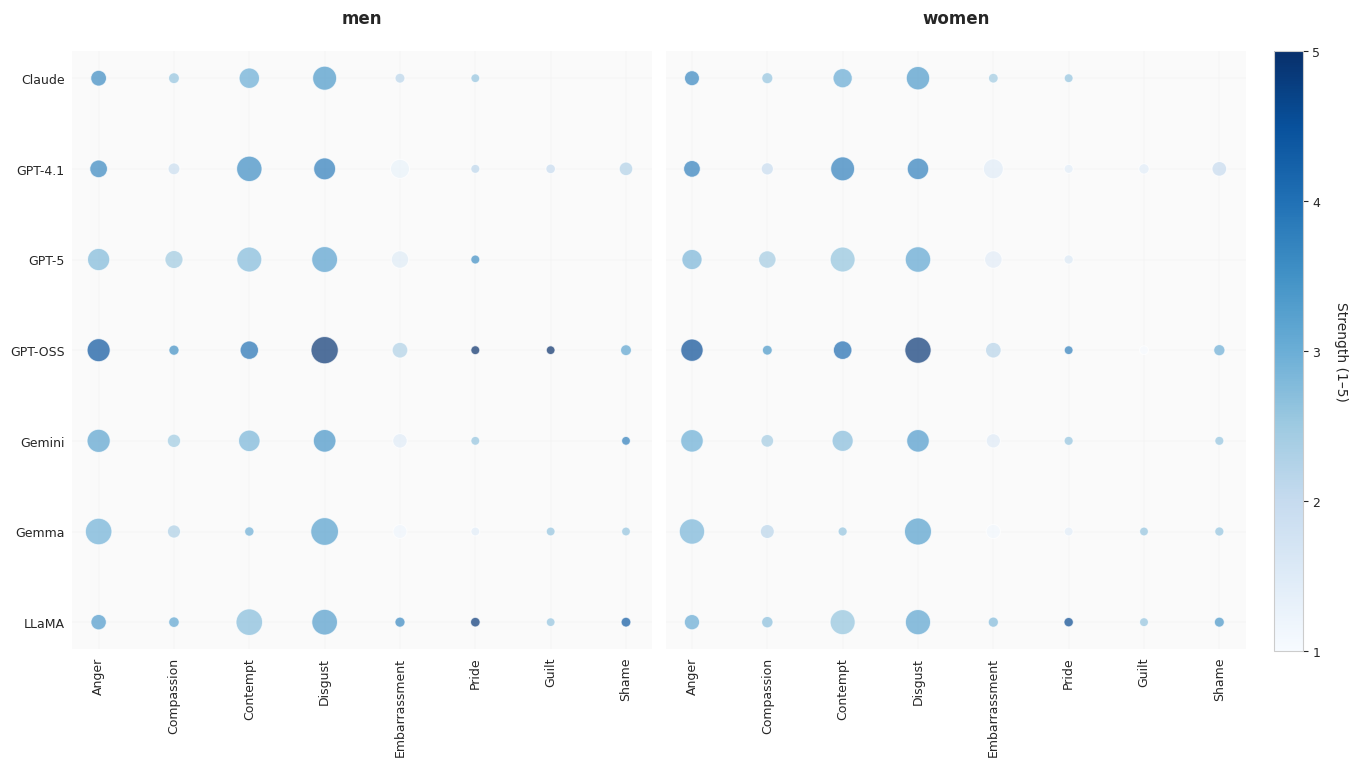

In [ ]:
plot_bubble(agg_gender_weak, "gender", "observer", plt_type='llm_weak_tie', palette="Blues")

### A man vs A woman

In [ ]:
expanded_dfs = []

for model_name, df in {
    "GPT-4.1": df_gpt_41_gender,
    "GPT-5": df_gpt_5_gender,
    "Gemma": df_gemma_gender,
    "Claude": df_claude_gender,
    "Gemini": df_gemini_gender,
    "GPT-OSS": df_gpt_oss_gender,
    "LLaMA": df_llama_gender
}.items():
    expanded_dfs.append(expand_strengths(df, "friends_emotion_strength", "friends", model_name))
    expanded_dfs.append(expand_strengths(df, "acquaintances_emotion_strength", "acquaintances", model_name))
    expanded_dfs.append(expand_strengths(df, "strangers_emotion_strength", "strangers", model_name))

df_all_gender = pd.concat(expanded_dfs, ignore_index=True)
df_all_gender["tie_strength"] = df_all_gender["actor"].map(tie_map)
df_all_gender = df_all_gender[df_all_gender["emotion"].isin(emotions_keep)].reset_index(drop=True)
df_all_gender

,ID,actor,gender,observer,emotion,strength,tie_strength
0,1,friends,male,GPT-4.1,Shame,2,strong
1,1,friends,male,GPT-4.1,Guilt,3,strong
2,1,friends,female,GPT-4.1,Guilt,2,strong
3,1,friends,female,GPT-4.1,Shame,2,strong
4,2,friends,male,GPT-4.1,Contempt,2,strong
...,...,...,...,...,...,...,...
36131,450,strangers,female,LLaMA,Disgust,2,weak
36132,451,strangers,male,LLaMA,Disgust,4,weak
36133,451,strangers,male,LLaMA,Contempt,3,weak
36134,451,strangers,female,LLaMA,Disgust,4,weak


In [ ]:
agg_gender_strong = aggregate_by_gender(df_all_gender, tie="strong")
agg_gender_weak = aggregate_by_gender(df_all_gender, tie="weak")

/tmp/ipython-input-3608932637.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


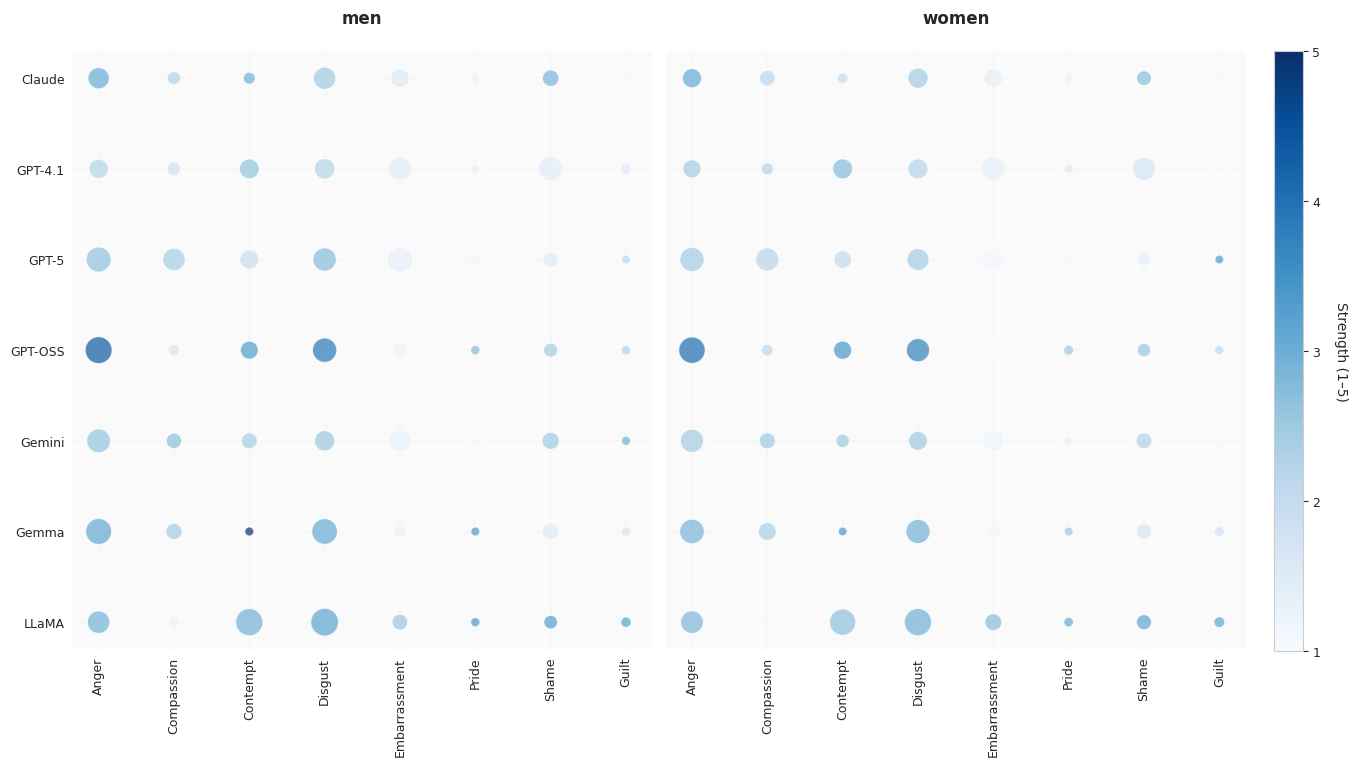

In [ ]:
plot_bubble(agg_gender_strong, "gender", "observer", plt_type='llm_strong_tie_no_names', palette="Blues")

/tmp/ipython-input-3608932637.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


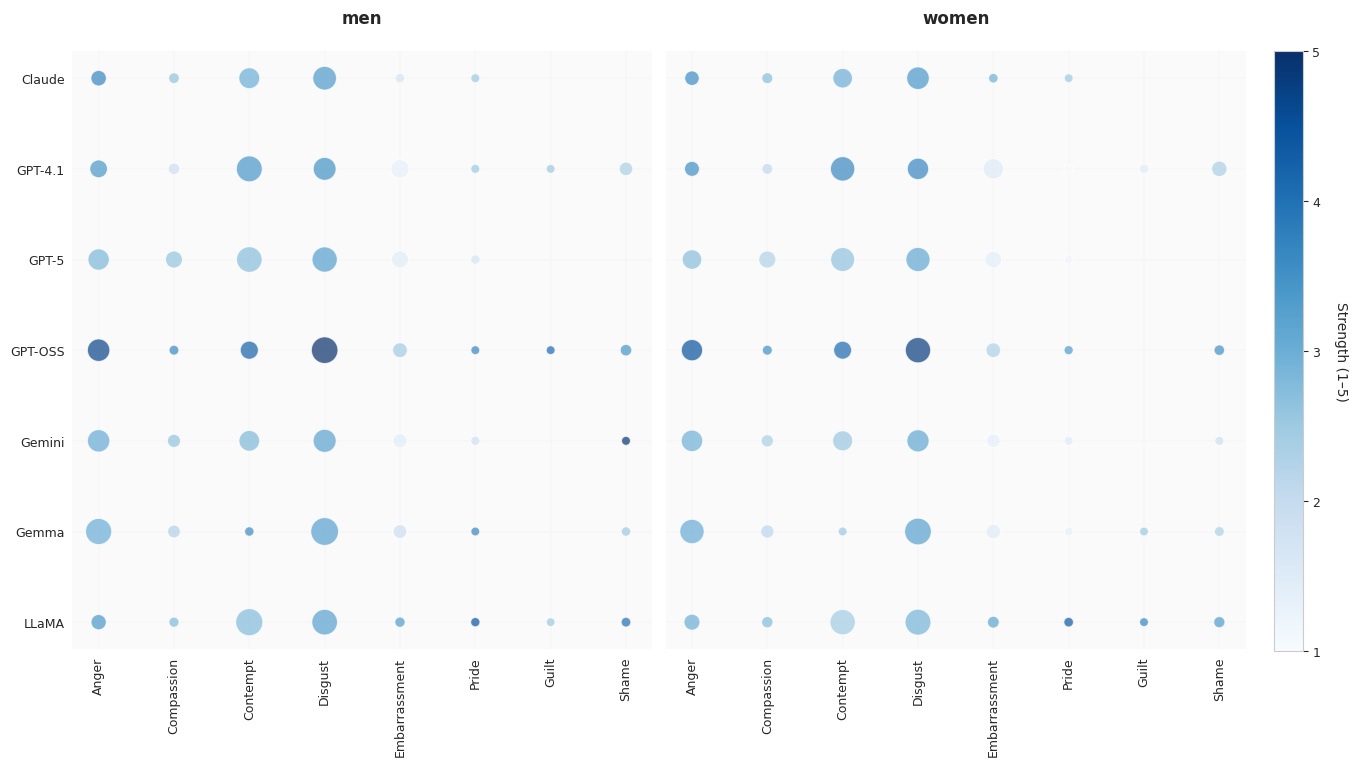

In [ ]:
plot_bubble(agg_gender_weak, "gender", "observer", plt_type='llm_weak_tie_no_names', palette="Blues")

# Moral Dimension Plots

## Self

In [ ]:
df_claude_mft = expand_strengths(df_claude, col="actor_emotion_strength", actor_label='self', observer_label="Claude")
df_claude_mft = df_claude_mft.merge(df_claude[["ID","MFT"]], on="ID", how="inner")
df_claude_mft = df_claude_mft[df_claude_mft["emotion"].isin(emotions_keep)].reset_index(drop=True)
df_claude_mft

,ID,actor,gender,observer,emotion,strength,MFT
0,1,self,male,Claude,Guilt,3,care-harm
1,1,self,male,Claude,Guilt,3,care-harm
2,1,self,male,Claude,Shame,2,care-harm
3,1,self,male,Claude,Shame,2,care-harm
4,1,self,female,Claude,Guilt,2,care-harm
...,...,...,...,...,...,...,...
2283,450,self,male,Claude,Guilt,4,sancticity-degradation
2284,450,self,female,Claude,Shame,3,sancticity-degradation
2285,450,self,female,Claude,Shame,3,sancticity-degradation
2286,450,self,female,Claude,Guilt,4,sancticity-degradation


In [ ]:
agg_mft = aggregate_emotions(df_claude_mft, ["MFT", "gender", "emotion"])
agg_mft

,MFT,gender,emotion,frequency,avg_strength,std_strength,ci_lower,ci_upper
0,authority-subversion,female,Anger,30,2.866667,0.507416,2.677194,3.056139
1,authority-subversion,female,Disgust,4,2.500000,0.577350,1.581307,3.418693
2,authority-subversion,female,Embarrassment,28,2.071429,0.262265,1.969733,2.173124
3,authority-subversion,female,Guilt,52,2.615385,0.690378,2.423182,2.807587
4,authority-subversion,female,Pride,30,2.200000,0.406838,2.048084,2.351916
...,...,...,...,...,...,...,...,...
62,sancticity-degradation,male,Disgust,20,2.700000,0.656947,2.392539,3.007461
63,sancticity-degradation,male,Embarrassment,76,2.473684,0.756724,2.300765,2.646603
64,sancticity-degradation,male,Guilt,56,2.964286,0.785419,2.753949,3.174622
65,sancticity-degradation,male,Pride,20,2.600000,0.502625,2.364764,2.835236


/tmp/ipython-input-3608932637.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


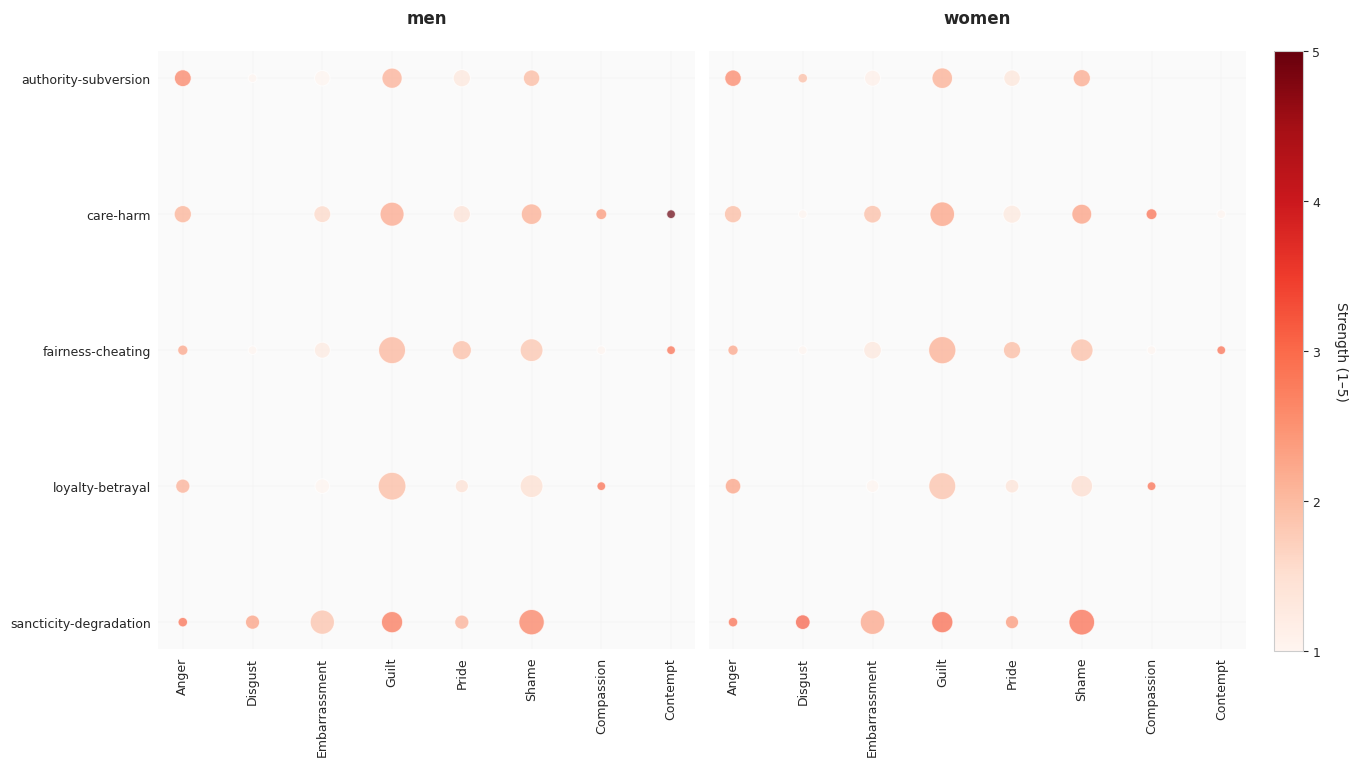

In [ ]:
plot_bubble(agg_mft, "gender", "MFT", plt_type='mft_self', palette="Reds")

## Others

In [ ]:
expanded_dfs = []

expanded_dfs.append(expand_strengths(df_claude, "friends_emotion_strength", "friends", 'claude'))
expanded_dfs.append(expand_strengths(df_claude, "acquaintances_emotion_strength", "acquaintances", 'claude'))
expanded_dfs.append(expand_strengths(df_claude, "strangers_emotion_strength", "strangers", 'claude'))

df_claude_mft = pd.concat(expanded_dfs, ignore_index=True)
df_claude_mft = df_claude_mft.merge(df_claude[["ID","MFT"]], on="ID", how="inner")
df_claude_mft["tie_strength"] = df_claude_mft["actor"].map(tie_map)
df_claude_mft = df_claude_mft[df_claude_mft["emotion"].isin(emotions_keep)].reset_index(drop=True)
df_claude_mft

,ID,actor,gender,observer,emotion,strength,MFT,tie_strength
0,1,friends,male,claude,Anger,3,care-harm,strong
1,1,friends,male,claude,Anger,3,care-harm,strong
2,1,friends,male,claude,Disgust,2,care-harm,strong
3,1,friends,male,claude,Disgust,2,care-harm,strong
4,1,friends,male,claude,Shame,2,care-harm,strong
...,...,...,...,...,...,...,...,...
6959,450,strangers,female,claude,Contempt,3,sancticity-degradation,weak
6960,451,strangers,male,claude,Disgust,3,sancticity-degradation,weak
6961,451,strangers,male,claude,Disgust,3,sancticity-degradation,weak
6962,451,strangers,female,claude,Disgust,3,sancticity-degradation,weak


In [ ]:
agg_mft_ties = aggregate_emotions(df_claude_mft, ["MFT", "tie_strength", "emotion"])
agg_mft_ties

,MFT,tie_strength,emotion,frequency,avg_strength,std_strength,ci_lower,ci_upper
0,authority-subversion,strong,Anger,146,2.780822,0.626904,2.678277,2.883367
1,authority-subversion,strong,Compassion,64,2.406250,0.555456,2.267501,2.544999
2,authority-subversion,strong,Contempt,6,2.666667,0.516398,2.124740,3.208593
3,authority-subversion,strong,Disgust,124,2.451613,0.642086,2.337477,2.565749
4,authority-subversion,strong,Embarrassment,134,2.119403,0.475644,2.038130,2.200676
5,authority-subversion,strong,Shame,36,2.833333,0.507093,2.661758,3.004909
6,authority-subversion,weak,Anger,130,2.292308,0.549082,2.197027,2.387589
7,authority-subversion,weak,Compassion,22,1.818182,0.588490,1.557260,2.079104
8,authority-subversion,weak,Contempt,136,2.117647,0.404765,2.049005,2.186289
9,authority-subversion,weak,Disgust,282,2.170213,0.619464,2.097600,2.242826


/tmp/ipython-input-3608932637.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


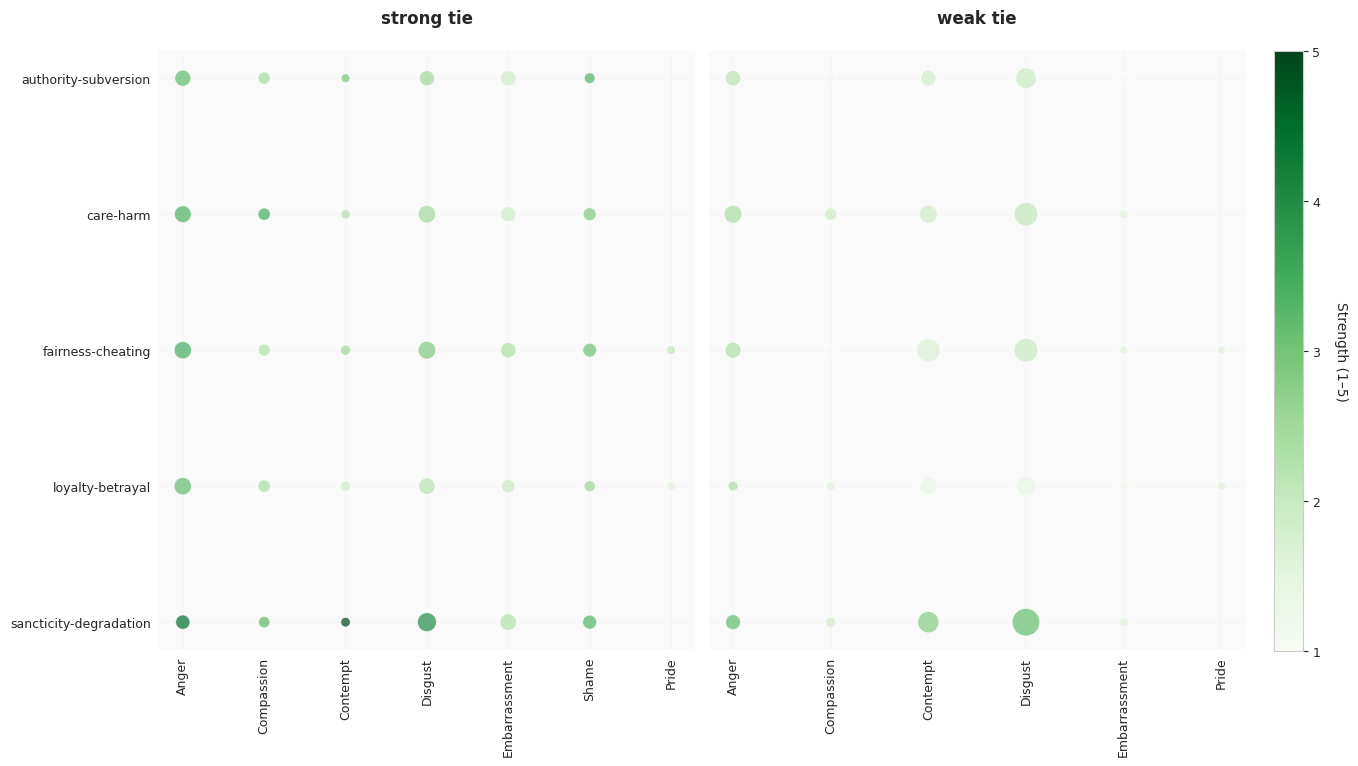

In [ ]:
plot_bubble(agg_mft_ties, "tie_strength", "MFT", plt_type='mft_others', palette="Greens")

### Gender Differences

In [ ]:
agg_gender_strong = aggregate_by_gender(df_claude_mft, tie="strong", col='MFT')
agg_gender_weak = aggregate_by_gender(df_claude_mft, tie="weak", col='MFT')

/tmp/ipython-input-3608932637.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


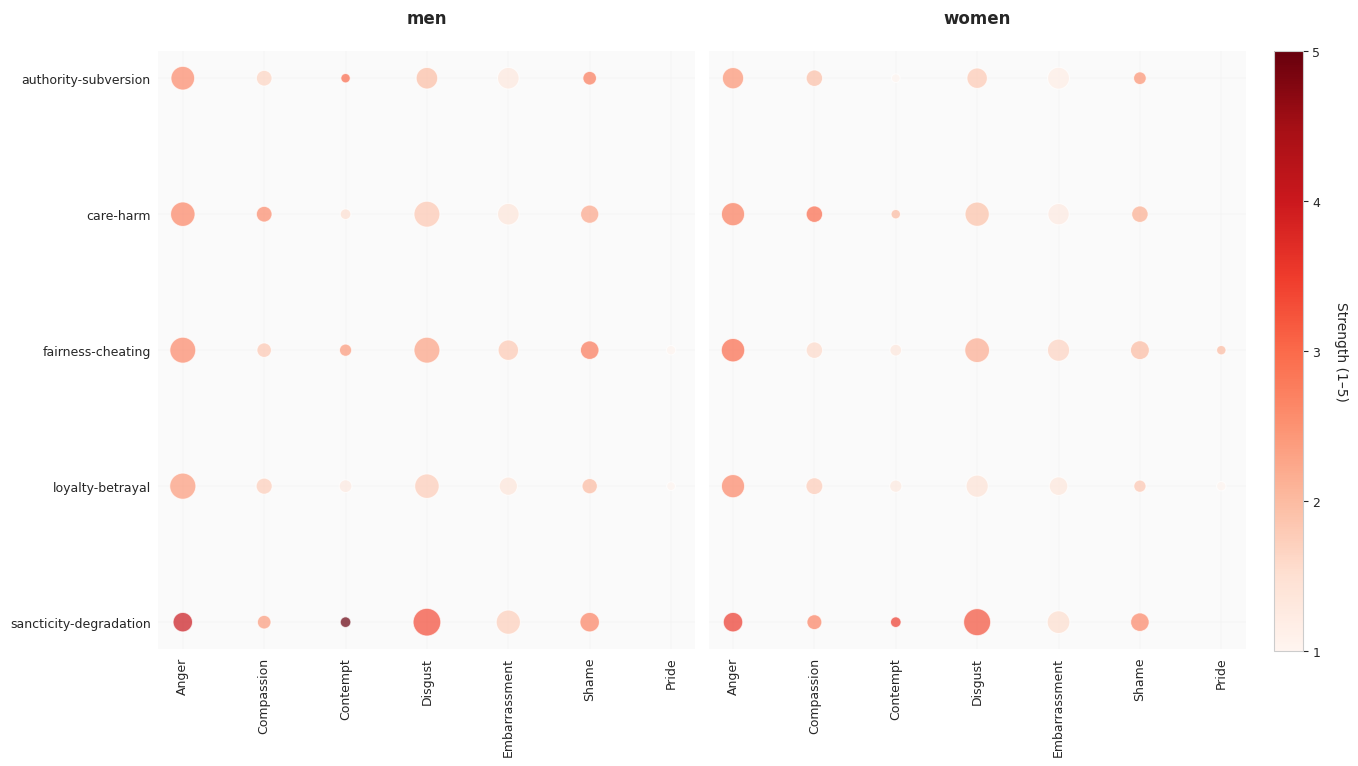

In [ ]:
plot_bubble(agg_gender_strong, "gender", "MFT", plt_type='mft_strong_tie', palette="Reds")

/tmp/ipython-input-3608932637.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


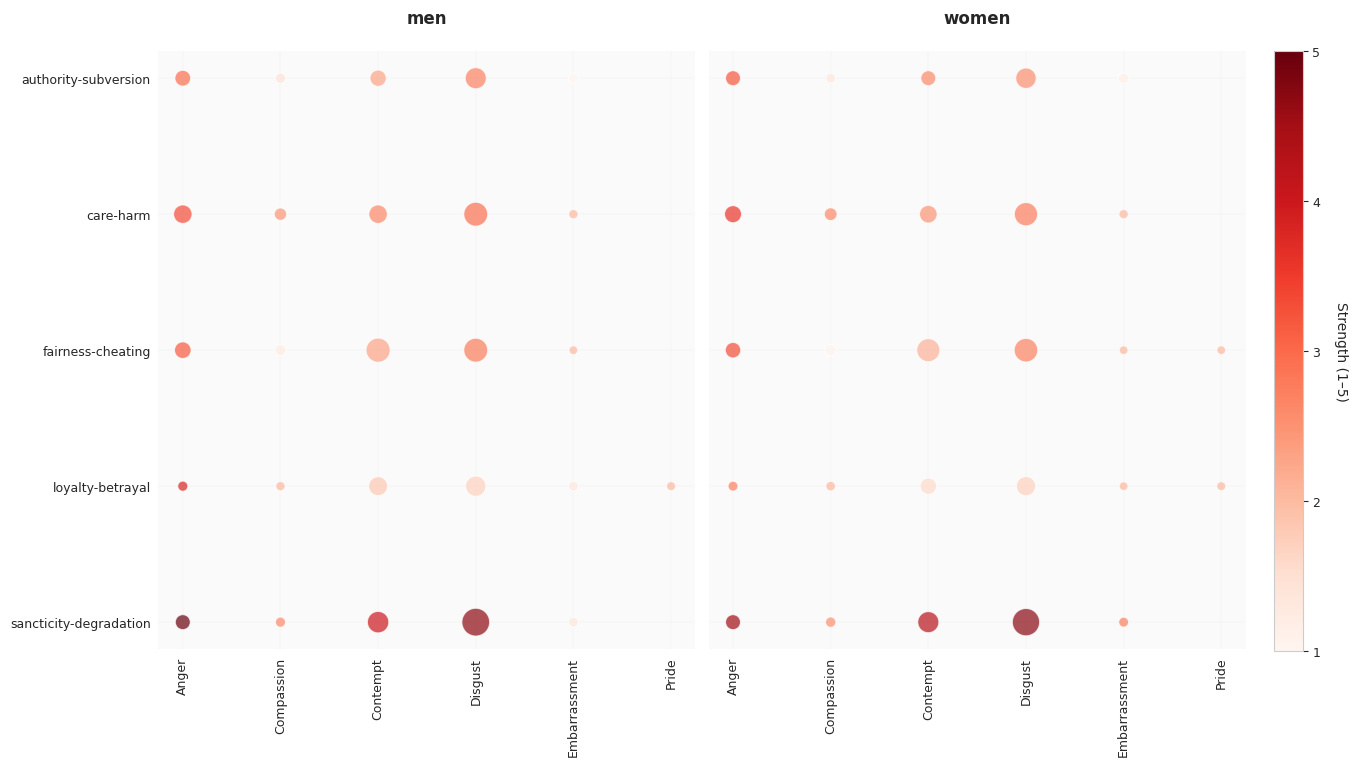

In [ ]:
plot_bubble(agg_gender_weak, "gender", "MFT", plt_type='mft_weak_tie', palette="Reds")

# Harm Distribution Plots

In [112]:
df_harm = pd.read_csv(folder_path+'gpt_harm_eval_responses.csv')
df_harm = df_harm.rename(columns={'actor_gender': 'gender'})
df_harm

,ID,actor,stimuli,gender,harm_society,harm_family_friend,harm_acquaintance,harm_stranger,input_tokens,output_tokens,total_tokens
0,1,Maria,Maria did not tell someone's girlfriend that h...,female,2,1,3,1,234,809,1043
1,1,William,William did not tell someone's girlfriend that...,male,2,4,1,1,234,745,979
2,2,Mary,Mary rarely talks to her elderly roommates and...,female,1,1,2,1,243,681,924
3,2,John,John rarely talks to his elderly roommates and...,male,1,1,3,1,243,617,860
4,3,Robert,Robert stayed up until 5 am because he assumed...,male,1,2,1,1,241,745,986
...,...,...,...,...,...,...,...,...,...,...,...
897,449,Richard,Richard reads things in a British accent even ...,male,1,1,1,1,234,361,595
898,450,Elizabeth,Elizabeth touched a passed-out guy inappropria...,female,4,5,5,5,232,553,785
899,450,Charles,Charles touched a passed-out girl inappropriat...,male,4,5,5,5,232,873,1105
900,451,David,David smells his socks and underwear every tim...,male,1,1,1,1,240,169,409


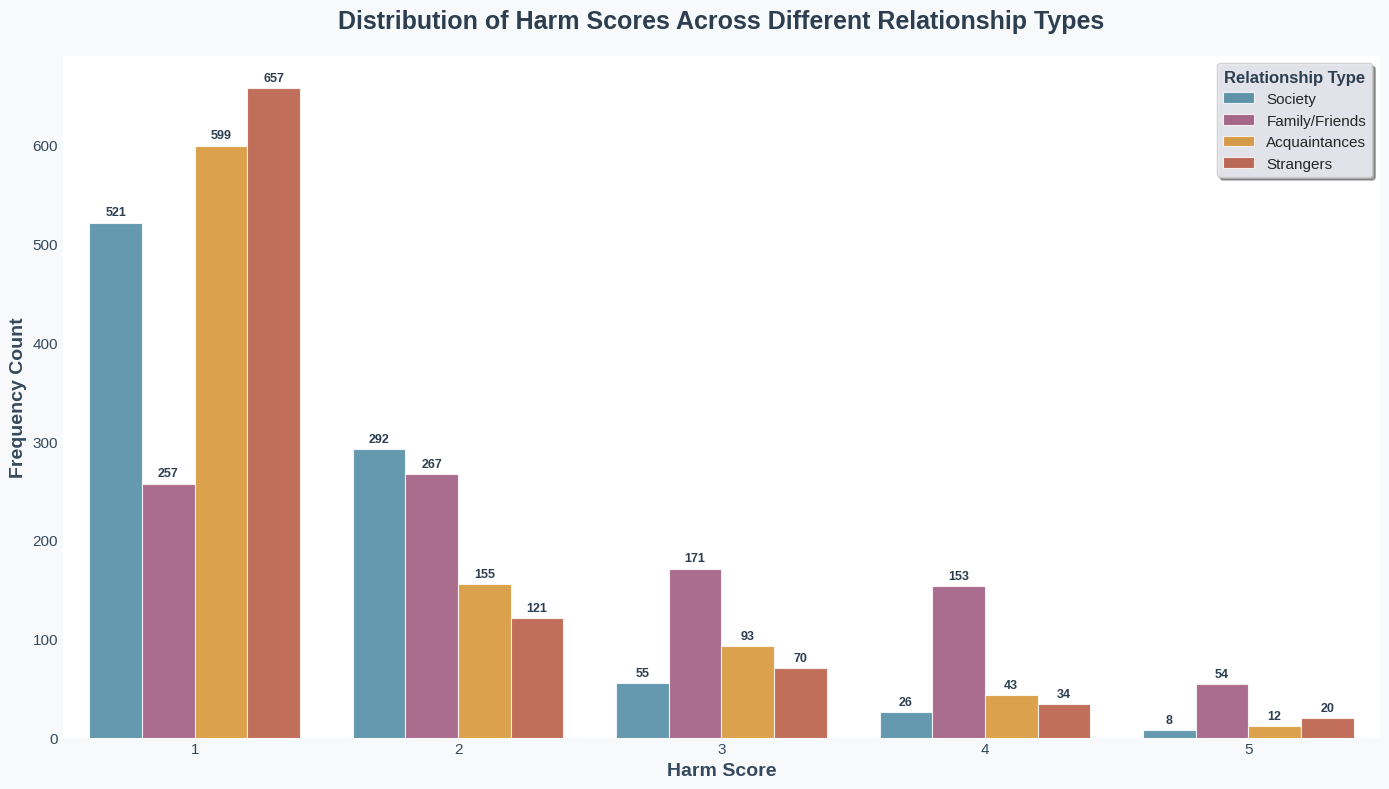

In [130]:
# Make sure harm columns are integers
harm_cols = ["harm_society", "harm_family_friend", "harm_acquaintance", "harm_stranger"]
df_harm[harm_cols] = df_harm[harm_cols].astype(int)

# Create a modern, visually appealing plot
plt.style.use('seaborn-v0_8-darkgrid')
fig, ax = plt.subplots(figsize=(14, 8))

# Prepare data for visualization
df_melt = df_harm.melt(value_vars=harm_cols, var_name="Harm Type", value_name="Score")

# Create a more readable mapping for harm types
harm_type_mapping = {
    "harm_society": "Society",
    "harm_family_friend": "Family/Friends",
    "harm_acquaintance": "Acquaintances",
    "harm_stranger": "Strangers"
}
df_melt["Harm Type"] = df_melt["Harm Type"].map(harm_type_mapping)

# Define a sophisticated color palette
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']

# Create the countplot with enhanced styling
sns.countplot(data=df_melt, x="Score", hue="Harm Type",
              palette=colors, alpha=0.8, edgecolor='white', linewidth=0.8)

# Enhance the plot appearance
plt.title("Distribution of Harm Scores Across Different Relationship Types",
          fontsize=18, fontweight='bold', pad=20, color='#2C3E50')
plt.xlabel("Harm Score", fontsize=14, fontweight='semibold', color='#34495E')
plt.ylabel("Frequency Count", fontsize=14, fontweight='semibold', color='#34495E')

# Customize legend
legend = plt.legend(title="Relationship Type", title_fontsize=12, fontsize=11,
                   loc='upper right', frameon=True, fancybox=True,
                   shadow=True, framealpha=0.9)
legend.get_title().set_fontweight('bold')
legend.get_title().set_color('#2C3E50')

# Customize tick parameters
plt.xticks(fontsize=11, color='#34495E')
plt.yticks(fontsize=11, color='#34495E')

# Add subtle grid for better readability
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax.set_axisbelow(True)

# Adjust layout and add subtle background color
fig.patch.set_facecolor('#F8F9FA')
ax.set_facecolor('#FFFFFF')

# Add value labels on top of bars for better insights
for container in ax.containers:
    ax.bar_label(container, fontsize=9, fontweight='semibold',
                color='#2C3E50', padding=3)

plt.tight_layout()
plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-darkgrid')
fig, ax = plt.subplots(figsize=(14, 8))

# Choose an aesthetically pleasing color palette
palette = ["#4E79A7", "#F28E2C", "#E15759", "#76B7B2"]

# Plot
sns.barplot(
    data=grouped,
    x="Score",
    y="Proportion",
    hue="Harm Type",
    palette=palette,
    alpha=0.85,
    edgecolor='white',
    linewidth=0.8,
    ax=ax
)

# Enhance the plot as before
plt.title("Proportion of Harm Scores Across Different Relationship Types",
          fontsize=18, fontweight='bold', pad=20, color='#2C3E50')
plt.xlabel("Harm Score", fontsize=14, fontweight='semibold', color='#34495E')
plt.ylabel("Proportion", fontsize=14, fontweight='semibold', color='#34495E')

# Customize legend
legend = plt.legend(title="Relationship Type", title_fontsize=12, fontsize=11,
                   loc='upper right', frameon=True, fancybox=True,
                   shadow=True, framealpha=0.9)
legend.get_title().set_fontweight('bold')
legend.get_title().set_color('#2C3E50')

plt.xticks(fontsize=11, color='#34495E')
plt.yticks(fontsize=11, color='#34495E')
plt.ylim(0, grouped["Proportion"].max() * 1.12)  # Some space for labels

ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax.set_axisbelow(True)
fig.patch.set_facecolor('#F8F9FA')
ax.set_facecolor('#FFFFFF')

# Add percent labels
for c in ax.containers:
    ax.bar_label(c, labels=[f"{v.get_height()*100:.1f}%" if v.get_height() > 0 else "" for v in c],
                 fontsize=9, fontweight='semibold', color='#2C3E50', padding=3)

plt.tight_layout()
plt.show()

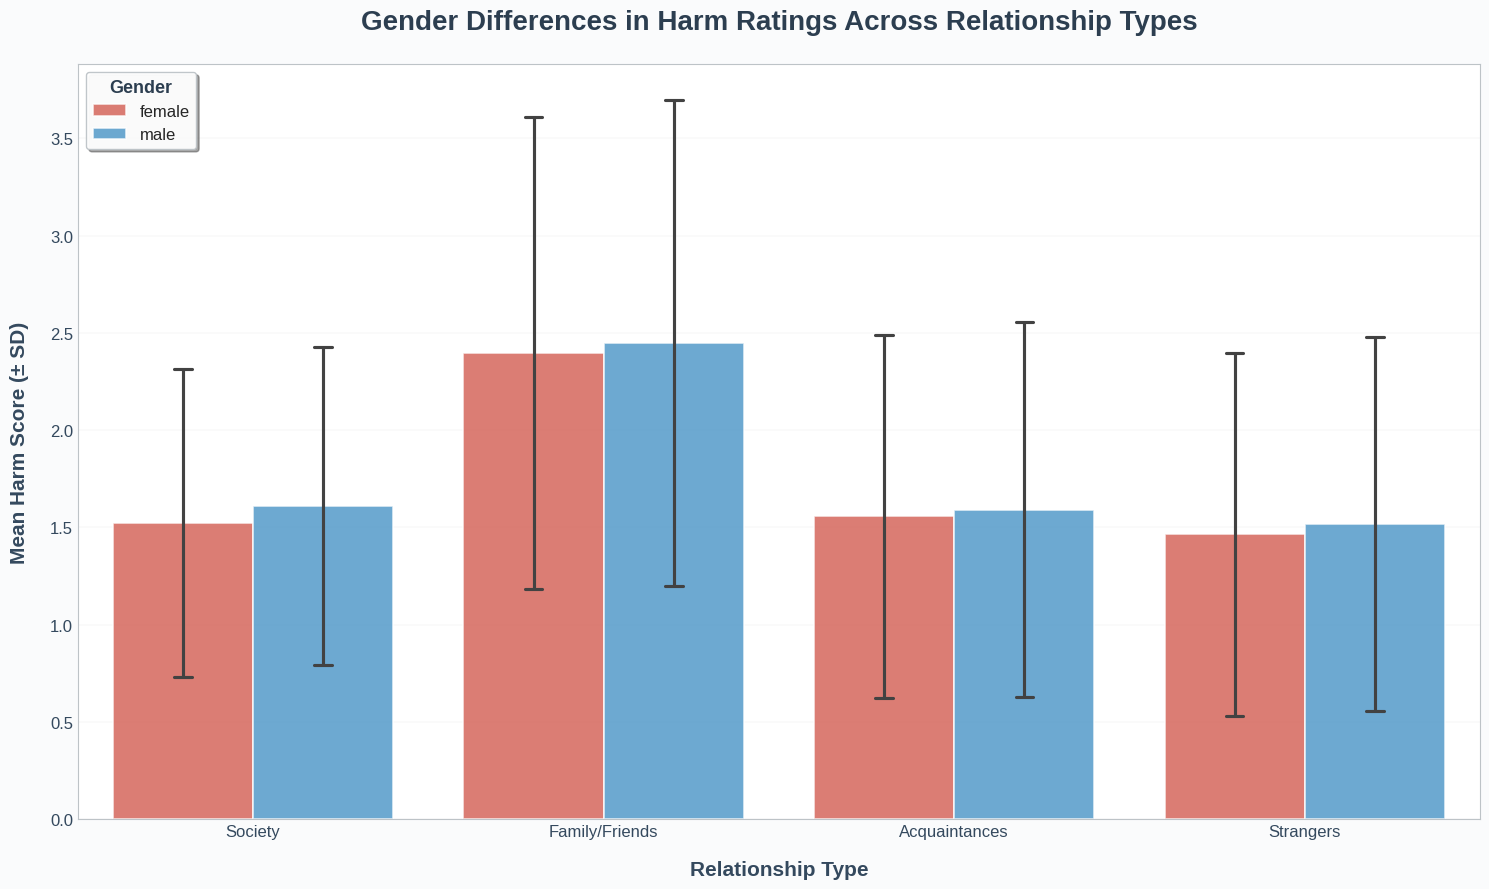

In [134]:
# Gender differences analysis with enhanced visualization
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(15, 9))

# Prepare data for visualization
df_melt_gender = df_harm.melt(
    id_vars="gender", value_vars=harm_cols, var_name="Harm Type", value_name="Score"
)

# Create readable mappings
harm_type_mapping = {
    "harm_society": "Society",
    "harm_family_friend": "Family/Friends",
    "harm_acquaintance": "Acquaintances",
    "harm_stranger": "Strangers"
}
df_melt_gender["Harm Type"] = df_melt_gender["Harm Type"].map(harm_type_mapping)

# Define sophisticated color palette for gender
gender_colors = {
    'Male': '#3498DB',      # Professional blue
    'Female': '#E74C3C',    # Elegant red
    'Other': '#9B59B6',     # Purple for other/non-binary
    'male': '#3498DB',      # Handle lowercase variations
    'female': '#E74C3C',
    'other': '#9B59B6'
}

# Create the enhanced barplot
sns.barplot(data=df_melt_gender, x="Harm Type", y="Score", hue="gender",
            palette=gender_colors, alpha=0.8, errorbar="sd", capsize=0.1,
            edgecolor='white', linewidth=1.2)

# Enhance plot appearance
plt.title("Gender Differences in Harm Ratings Across Relationship Types",
          fontsize=20, fontweight='bold', pad=25, color='#2C3E50')
plt.xlabel("Relationship Type", fontsize=15, fontweight='semibold',
           color='#34495E', labelpad=15)
plt.ylabel("Mean Harm Score (± SD)", fontsize=15, fontweight='semibold',
           color='#34495E', labelpad=15)

# Rotate x-axis labels for better readability
plt.xticks(ha='center', fontsize=12, color='#34495E')
plt.yticks(fontsize=12, color='#34495E')

# Enhance legend
legend = plt.legend(title="Gender", title_fontsize=13, fontsize=12,
                   loc='upper left', frameon=True, fancybox=True,
                   shadow=True, framealpha=0.95, edgecolor='#BDC3C7')
legend.get_title().set_fontweight('bold')
legend.get_title().set_color('#2C3E50')

# Customize grid and background
ax.grid(True, alpha=0.4, linestyle='-', linewidth=0.3, axis='y')
ax.set_axisbelow(True)
fig.patch.set_facecolor('#FAFBFC')
ax.set_facecolor('#FFFFFF')

# Add subtle border around the plot
for spine in ax.spines.values():
    spine.set_color('#BDC3C7')
    spine.set_linewidth(0.8)

plt.tight_layout()
plt.show()

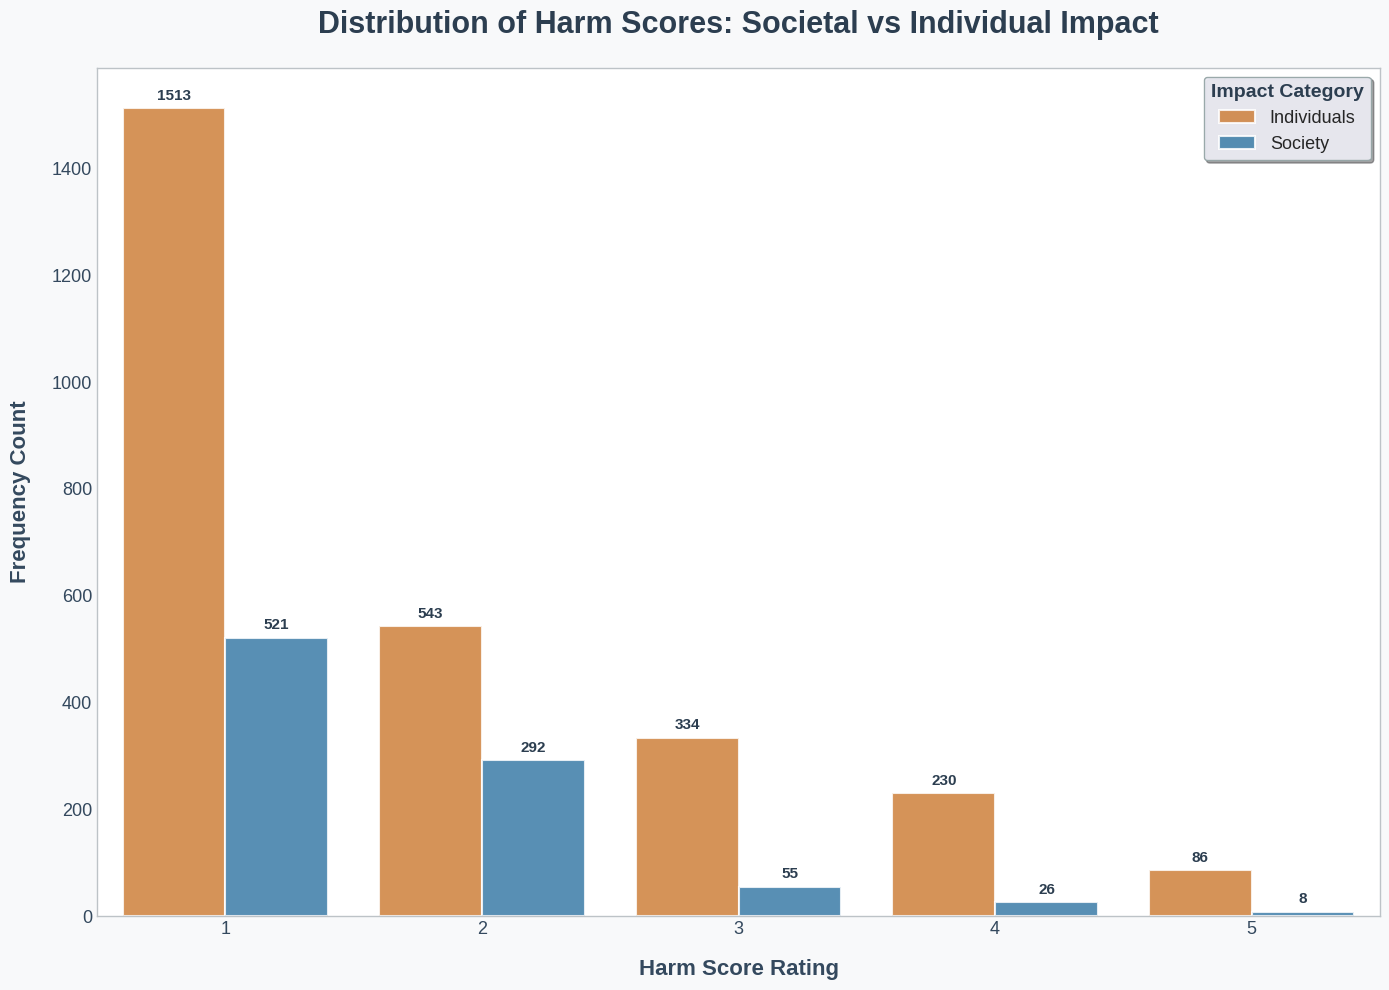

In [137]:
# Melt the three individual columns into long format, keeping gender
df_individuals = df_harm.melt(
    id_vars=["gender"],
    value_vars=["harm_family_friend", "harm_acquaintance", "harm_stranger"],
    var_name="Relation",
    value_name="Score"
)
df_individuals["Harm Category"] = "Individuals"

# Society column as its own frame, keeping gender
df_society = df_harm[["gender", "harm_society"]].copy()
df_society = df_society.rename(columns={"harm_society": "Score"})
df_society["Harm Category"] = "Society"

# Combine datasets
df_two = pd.concat([df_individuals[["gender", "Score", "Harm Category"]],
                    df_society[["gender", "Score", "Harm Category"]]],
                   ignore_index=True)

# Create enhanced visualization
plt.style.use('seaborn-v0_8-darkgrid')
fig, ax = plt.subplots(figsize=(14, 10))

# Define sophisticated color palette
category_colors = {
    'Individuals': '#E67E22',  # Warm orange for personal relationships
    'Society': '#2980B9'       # Professional blue for societal impact
}

# Create the enhanced countplot
sns.countplot(data=df_two, x="Score", hue="Harm Category",
              palette=category_colors, alpha=0.85,
              edgecolor='white', linewidth=1.5)

# Enhance plot appearance
plt.title("Distribution of Harm Scores: Societal vs Individual Impact",
          fontsize=22, fontweight='bold', pad=25, color='#2C3E50')
plt.xlabel("Harm Score Rating", fontsize=16, fontweight='semibold',
           color='#34495E', labelpad=15)
plt.ylabel("Frequency Count", fontsize=16, fontweight='semibold',
           color='#34495E', labelpad=15)

# Customize tick parameters
plt.xticks(fontsize=13, color='#34495E', fontweight='medium')
plt.yticks(fontsize=13, color='#34495E', fontweight='medium')

# Enhance legend with better styling
legend = plt.legend(title="Impact Category", title_fontsize=14, fontsize=13,
                   loc='upper right', frameon=True, fancybox=True,
                   shadow=True, framealpha=0.95, edgecolor='#95A5A6')
legend.get_title().set_fontweight('bold')
legend.get_title().set_color('#2C3E50')

# Customize grid and background
ax.grid(True, alpha=0.4, linestyle='--', linewidth=0.6)
ax.set_axisbelow(True)
fig.patch.set_facecolor('#F8F9FA')
ax.set_facecolor('#FFFFFF')

# Add value labels on top of bars
for container in ax.containers:
    ax.bar_label(container, fontsize=11, fontweight='bold',
                color='#2C3E50', padding=4)

# Add subtle border styling
for spine in ax.spines.values():
    spine.set_color('#BDC3C7')
    spine.set_linewidth(1.0)

plt.tight_layout()
plt.show()

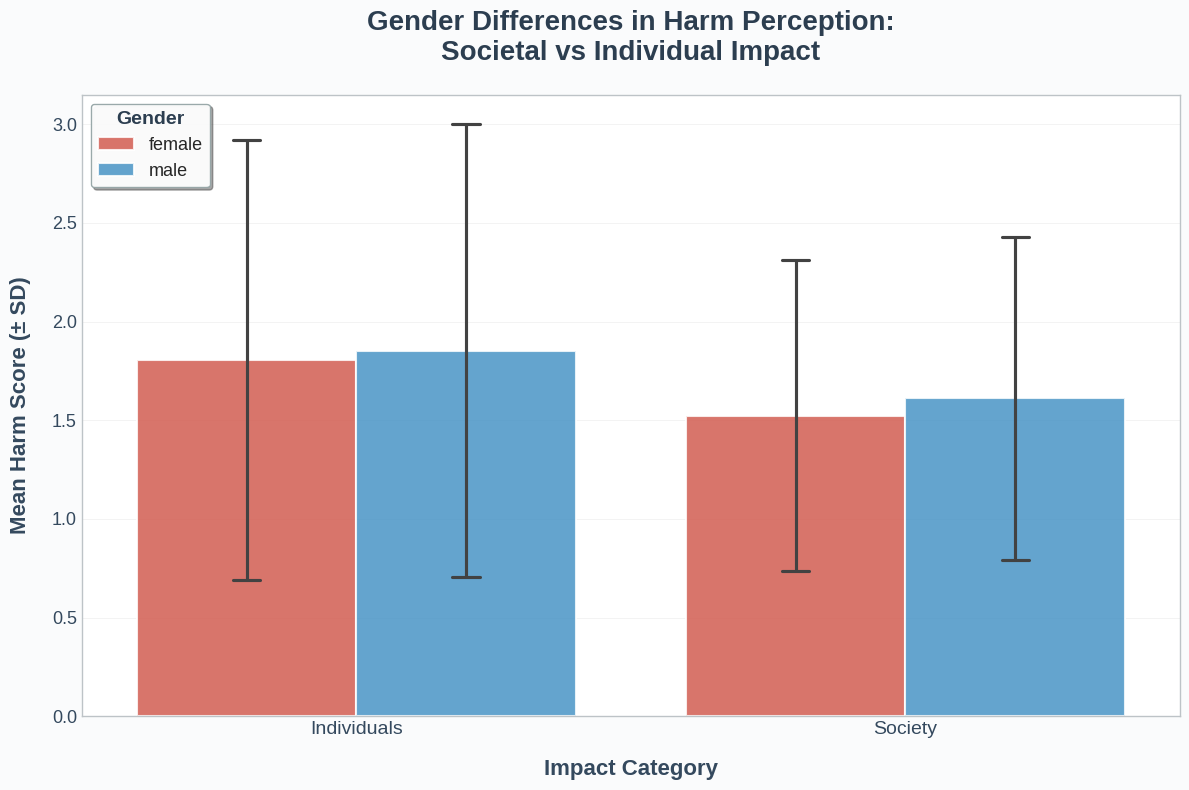

In [138]:
# Enhanced gender differences visualization for Society vs Individuals
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(12, 8))

# Define sophisticated color palette for gender
gender_colors = {
    'Male': '#3498DB',      # Professional blue
    'Female': '#E74C3C',    # Elegant red
    'Other': '#9B59B6',     # Purple for other/non-binary
    'male': '#3498DB',      # Handle lowercase variations
    'female': '#E74C3C',
    'other': '#9B59B6'
}

# Create the enhanced barplot
sns.barplot(
    data=df_two,
    x="Harm Category",
    y="Score",
    hue="gender",
    palette=gender_colors,
    alpha=0.85,
    errorbar="sd",
    capsize=0.1,
    edgecolor='white',
    linewidth=1.5
)

# Enhance plot appearance
plt.title("Gender Differences in Harm Perception:\nSocietal vs Individual Impact",
          fontsize=20, fontweight='bold', pad=25, color='#2C3E50')
plt.xlabel("Impact Category", fontsize=16, fontweight='semibold',
           color='#34495E', labelpad=15)
plt.ylabel("Mean Harm Score (± SD)", fontsize=16, fontweight='semibold',
           color='#34495E', labelpad=15)

# Customize tick parameters
plt.xticks(fontsize=14, color='#34495E', fontweight='medium')
plt.yticks(fontsize=13, color='#34495E')

# Enhance legend
legend = plt.legend(title="Gender", title_fontsize=14, fontsize=13,
                   loc='upper left', frameon=True, fancybox=True,
                   shadow=True, framealpha=0.95, edgecolor='#95A5A6')
legend.get_title().set_fontweight('bold')
legend.get_title().set_color('#2C3E50')

# Customize grid and background
ax.grid(True, alpha=0.4, linestyle='-', linewidth=0.4, axis='y')
ax.set_axisbelow(True)
fig.patch.set_facecolor('#FAFBFC')
ax.set_facecolor('#FFFFFF')

# Add subtle border styling
for spine in ax.spines.values():
    spine.set_color('#BDC3C7')
    spine.set_linewidth(1.0)

# Set y-axis to start from 0 for better comparison
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.show()

# LLM Humanness Plots

In [102]:
df_humanness = pd.read_csv(folder_path+'gpt_humanness_responses.csv')

In [103]:
for col in ['llm_expressed_emotions', 'llm_emotion_strength']:
    df_humanness[col] = df_humanness[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) and x.strip().startswith("{") else x)

df_humanness = df_humanness.rename(columns={'actor_gender': 'gender'})

In [104]:
# Select only the relevant metadata columns
meta = df[["ID", "MFT", "rot-agree", "action-agree", "action-pressure", "action-hypothetical"]]

# Merge each model dataframe with the metadata
df_humanness  = df_humanness.merge(meta, on="ID", how="inner")
df_humanness

,ID,actor,stimuli,gender,llm_expressed_emotions,llm_emotion_strength,llm_response_action,user_behavior_inappropriateness,user_behavior_wrongness,input_tokens,output_tokens,total_tokens,MFT,rot-agree,action-agree,action-pressure,action-hypothetical
0,1,William,William did not tell someone's girlfriend that...,male,"{'emotions': ['Compassion'], 'no_emotion': Fal...","{'Compassion': 3.0, 'Concern': 3.0}",3,4,4,834,1280,2114,care-harm,4,4,2,explicit-no
1,1,Maria,Maria did not tell someone's girlfriend that h...,female,"{'emotions': ['Compassion'], 'no_emotion': Fal...","{'Compassion': 3.0, 'Concern': 2.0}",4,2,2,834,1088,1922,care-harm,4,4,2,explicit-no
2,2,John,John rarely talks to his elderly roommates and...,male,"{'emotions': ['Compassion'], 'no_emotion': Fal...","{'Compassion': 3.0, 'Concern': 2.0}",3,2,2,843,1344,2187,care-harm,3,3,1,explicit-no
3,2,Mary,Mary rarely talks to her elderly roommates and...,female,"{'emotions': ['Compassion'], 'no_emotion': Fal...","{'Compassion': 3.0, 'Concern': 2.0}",4,2,2,843,1024,1867,care-harm,3,3,1,explicit-no
4,3,Robert,Robert stayed up until 5 am because he assumed...,male,"{'emotions': ['Compassion'], 'no_emotion': Fal...",{'Compassion': 2.0},4,2,2,841,954,1795,care-harm,3,2,0,hypothetical
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
897,449,Richard,Richard reads things in a British accent even ...,male,"{'emotions': [], 'no_emotion': True, 'other_em...",NaN,2,1,1,834,436,1270,sancticity-degradation,2,2,-1,explicit
898,450,Elizabeth,Elizabeth touched a passed-out guy inappropria...,female,"{'emotions': ['Disgust', 'Compassion'], 'no_em...","{'Compassion': 3.0, 'Concern': 4.0, 'Disgust':...",4,5,5,832,1800,2632,sancticity-degradation,4,4,-2,explicit
899,450,Charles,Charles touched a passed-out girl inappropriat...,male,"{'emotions': ['Disgust', 'Anger', 'Compassion'...","{'Anger': 3.0, 'Compassion': 2.0, 'Disgust': 4.0}",4,5,5,832,1162,1994,sancticity-degradation,4,4,-2,explicit
900,451,Linda,Linda smells her socks and underwear every tim...,female,"{'emotions': ['Compassion'], 'no_emotion': Fal...",{'Compassion': 2.0},2,1,1,840,954,1794,sancticity-degradation,2,2,0,explicit


In [61]:
df_llm = expand_strengths(df_humanness, 'llm_emotion_strength', actor_label='llm', observer_label='GPT')
df_llm = df_llm.drop(columns=["actor"])
df_llm = df_llm.merge(df_humanness[["ID","MFT"]], on="ID", how="inner")
df_llm

,ID,gender,observer,emotion,strength,MFT
0,1,male,GPT,Compassion,3.0,care-harm
1,1,male,GPT,Compassion,3.0,care-harm
2,1,male,GPT,Concern,3.0,care-harm
3,1,male,GPT,Concern,3.0,care-harm
4,1,female,GPT,Compassion,3.0,care-harm
...,...,...,...,...,...,...
3089,450,male,GPT,Disgust,4.0,sancticity-degradation
3090,451,female,GPT,Compassion,2.0,sancticity-degradation
3091,451,female,GPT,Compassion,2.0,sancticity-degradation
3092,451,male,GPT,Compassion,2.0,sancticity-degradation


## Overall Emotion-Gender differences

In [62]:
agg_df_human = aggregate_emotions(df_llm, ["observer", "gender", "emotion"])
agg_df_human

,observer,gender,emotion,frequency,avg_strength,std_strength,ci_lower,ci_upper
0,GPT,female,Alarm,2,4.000000,0.000000,4.000000,4.000000
1,GPT,female,Anger,22,2.363636,0.657952,2.071917,2.655356
2,GPT,female,Compassion,882,2.476190,0.567768,2.438669,2.513712
3,GPT,female,Concern,472,2.720339,0.595604,2.666468,2.774210
4,GPT,female,Disappointment,30,2.266667,0.449776,2.098717,2.434616
5,GPT,female,Disapproval,4,3.500000,0.577350,2.581307,4.418693
6,GPT,female,Disgust,50,2.520000,0.814160,2.288618,2.751382
7,GPT,female,Embarrassment,8,1.750000,0.462910,1.362998,2.137002
8,GPT,female,Pride,18,2.111111,0.582983,1.821200,2.401022
9,GPT,female,Sadness,6,2.333333,0.516398,1.791407,2.875260


/tmp/ipython-input-2178983647.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(
/tmp/ipython-input-2178983647.py:27: UserWarning: The palette list has more values (14) than needed (11), which may not be intended.
  bars = sns.barplot(
/tmp/ipython-input-2178983647.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),
/tmp/ipython-input-2178983647.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(
/tmp/ipython-input-2178983647.py:27: UserWarning: The palette list has more values (14) than needed (12), which may not be intended.
  bars = sns.barplot

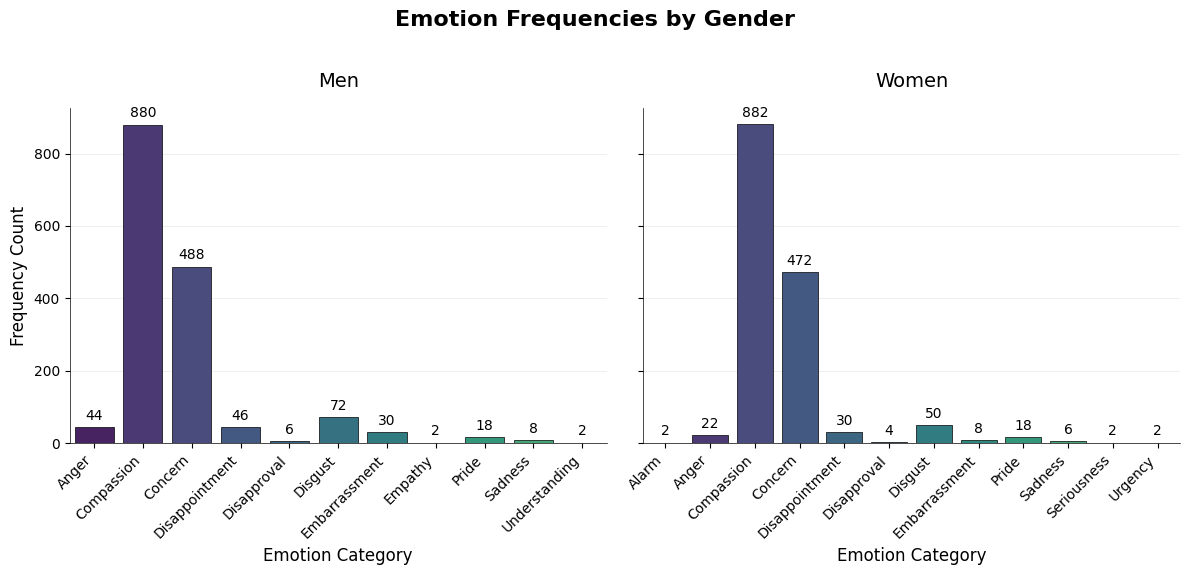

<Figure size 640x480 with 0 Axes>

In [63]:
agg_df_human["gender"] = agg_df_human["gender"].replace({
    "male": "men",
    "female": "women"
})

# Filter data for GPT observations only
df_gpt = agg_df_human[agg_df_human["observer"] == "GPT"].copy()

# Set publication-ready style
plt.style.use('default')
sns.set_palette("viridis")

# Create figure with appropriate size for publication
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
fig.suptitle("Emotion Frequencies by Gender",
             fontsize=16, fontweight='bold', y=0.95)

# Define colors for consistency
colors = sns.color_palette("viridis", n_colors=len(df_gpt["emotion"].unique()))

# Plot for each gender
for idx, (ax, gender) in enumerate(zip(axes, ["men", "women"])):
    # Filter data for current gender
    gender_data = df_gpt[df_gpt["gender"] == gender]

    # Create bar plot
    bars = sns.barplot(
        data=gender_data,
        x="emotion",
        y="frequency",
        palette=colors,
        edgecolor="black",
        linewidth=0.5,
        ax=ax
    )

    # Add value annotations on bars
    for bar in ax.patches:
        height = bar.get_height()
        if height > 0:
            ax.annotate(
                f'{int(height)}',
                xy=(bar.get_x() + bar.get_width()/2., height),
                xytext=(0, 3),
                textcoords='offset points',
                ha='center',
                va='bottom',
                fontsize=10,
                fontweight='medium'
            )

    # Customize subplot appearance
    ax.set_title(f'{gender.capitalize()}',
                fontsize=14, fontweight='medium', pad=15)
    ax.set_xlabel('Emotion Category', fontsize=12, fontweight='medium')

    # Set y-label only for left subplot
    if idx == 0:
        ax.set_ylabel('Frequency Count', fontsize=12, fontweight='medium')
    else:
        ax.set_ylabel('')

    # Rotate x-tick labels for better readability
    ax.set_xticklabels(ax.get_xticklabels(),
                      rotation=45,
                      ha='right',
                      fontsize=10)

    # Customize grid and spines
    ax.grid(axis='y', alpha=0.3, linestyle='-', linewidth=0.5)
    ax.set_axisbelow(True)

    # Remove top and right spines for cleaner look
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(0.5)
    ax.spines['bottom'].set_linewidth(0.5)

# Adjust layout to prevent label cutoff
plt.tight_layout(rect=[0, 0, 1, 0.93])

# Add subtle background color for better print quality
fig.patch.set_facecolor('white')

# Display the plot
plt.show()

# Optional: Save figure in high resolution for publication
plt.savefig('emotion_frequencies_by_gender.png',
            dpi=300,
            bbox_inches='tight',
            facecolor='white',
            edgecolor='none')

/tmp/ipython-input-1473151626.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


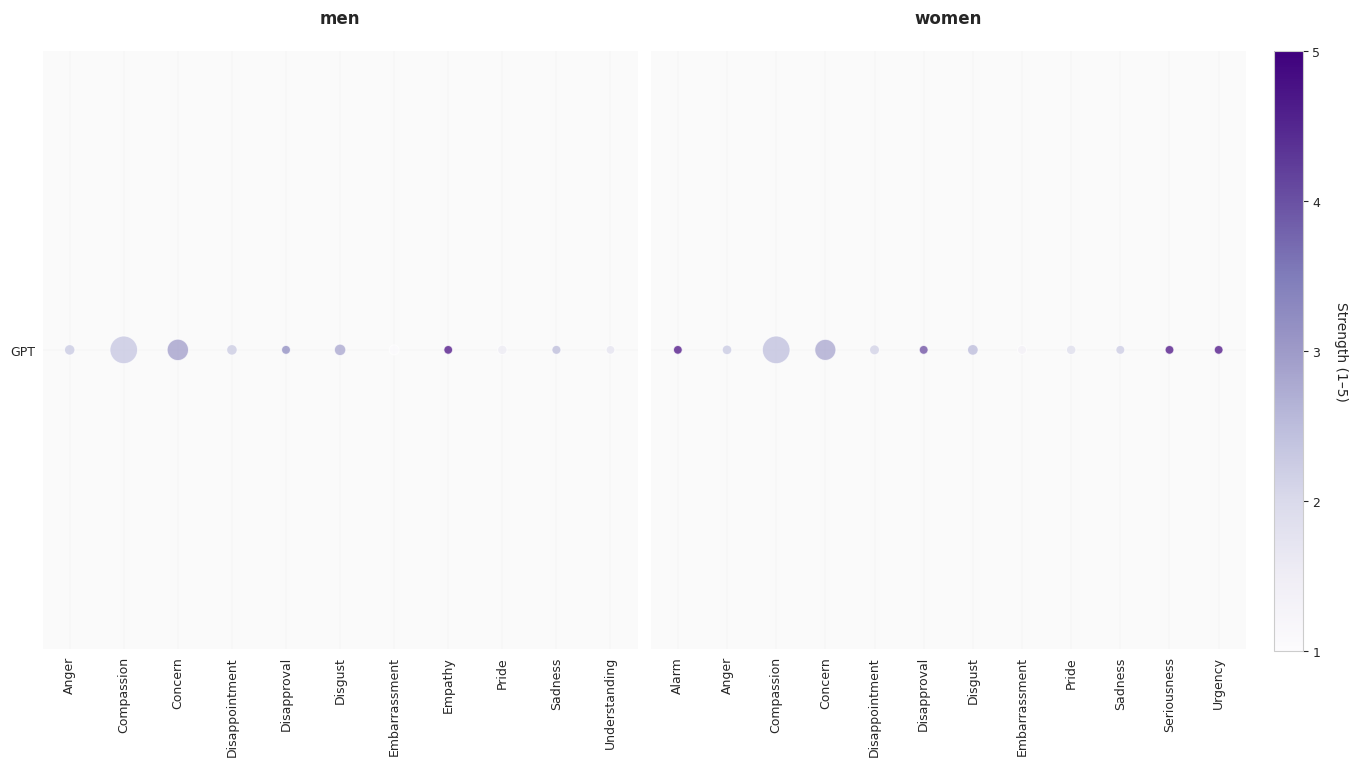

In [64]:
plot_bubble(agg_df_human, "gender", "observer", plt_type='gpt_humanness', palette="Purples")

## Moral Dimensions

In [65]:
agg_mft_gpt = aggregate_emotions(df_llm, ["MFT", "gender", "emotion"])
agg_mft_gpt

,MFT,gender,emotion,frequency,avg_strength,std_strength,ci_lower,ci_upper
0,authority-subversion,female,Anger,4,2.000000,0.000000,2.000000,2.000000
1,authority-subversion,female,Compassion,172,2.383721,0.555011,2.300186,2.467256
2,authority-subversion,female,Concern,98,2.530612,0.541172,2.422114,2.639110
3,authority-subversion,female,Disappointment,2,2.000000,0.000000,2.000000,2.000000
4,authority-subversion,female,Disgust,4,2.500000,0.577350,1.581307,3.418693
...,...,...,...,...,...,...,...,...
77,sancticity-degradation,male,Disapproval,2,3.000000,0.000000,3.000000,3.000000
78,sancticity-degradation,male,Disgust,36,2.777778,0.865567,2.484912,3.070644
79,sancticity-degradation,male,Embarrassment,12,1.500000,0.522233,1.168189,1.831811
80,sancticity-degradation,male,Pride,2,2.000000,0.000000,2.000000,2.000000


/tmp/ipython-input-1473151626.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


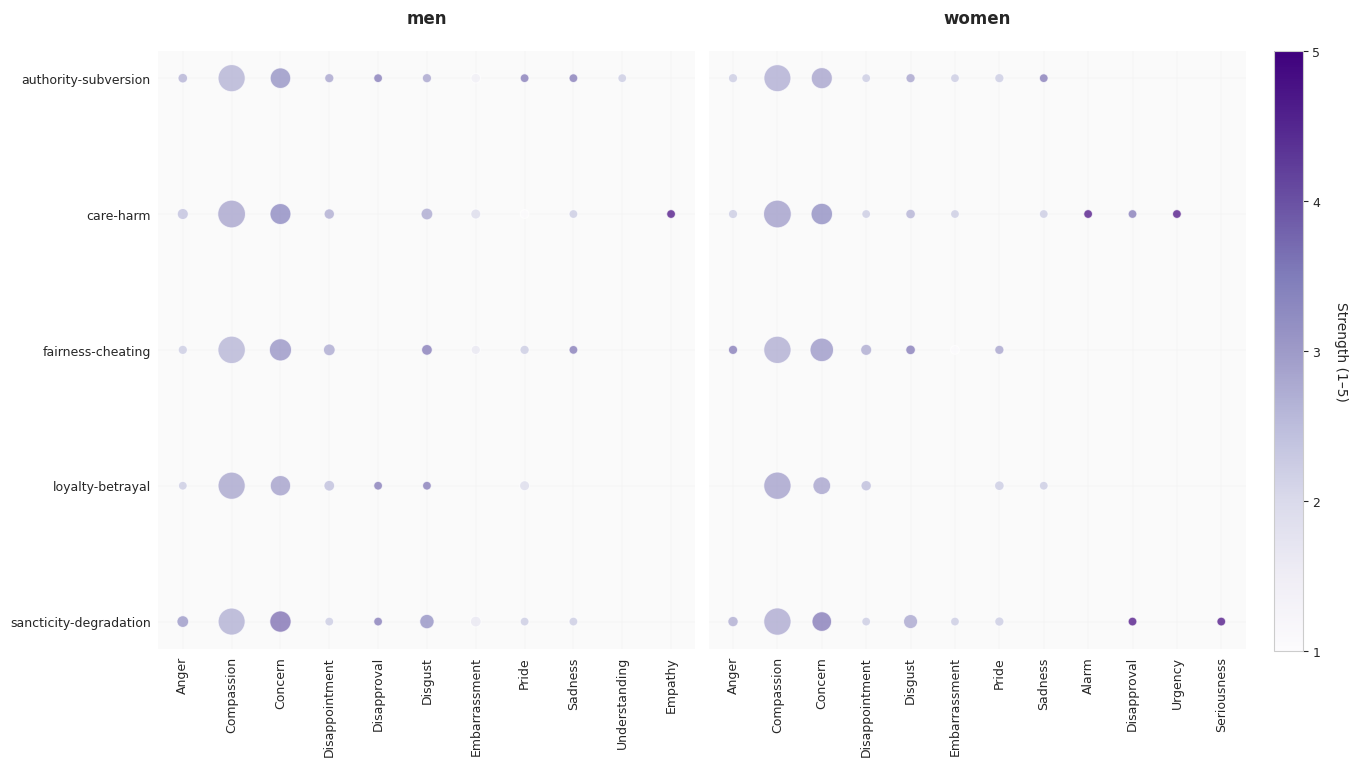

In [66]:
plot_bubble(agg_mft_gpt, "gender", "MFT", plt_type='gpt_humanness', palette="Purples")

## Action Analysis

In [79]:
ACTIONS = {
    1: "Ignore the behavior",
    2: "Express approval",
    3: "Express disapproval",
    4: "Warn about consequences",
    5: "Flag the user for inappropriate content"
}

In [99]:
df_humanness["llm_response_action"] = df_humanness["llm_response_action"].map(ACTIONS)
df_humanness["gender"] = df_humanness["gender"].replace({
    "male": "men",
    "female": "women"
})

In [101]:
action_counts = (
    df_humanness.groupby(["gender", "llm_response_action"])
    .size()
    .reset_index(name="count")
)
action_counts = action_counts.pivot(
    index="llm_response_action", columns="gender", values="count"
).fillna(0)
action_counts

gender,men,women
llm_response_action,,
Express approval,38,52
Express disapproval,154,131
Ignore the behavior,20,26
Warn about consequences,239,242


## Appropriateness-Wrongness

/tmp/ipython-input-3521586002.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipython-input-3521586002.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


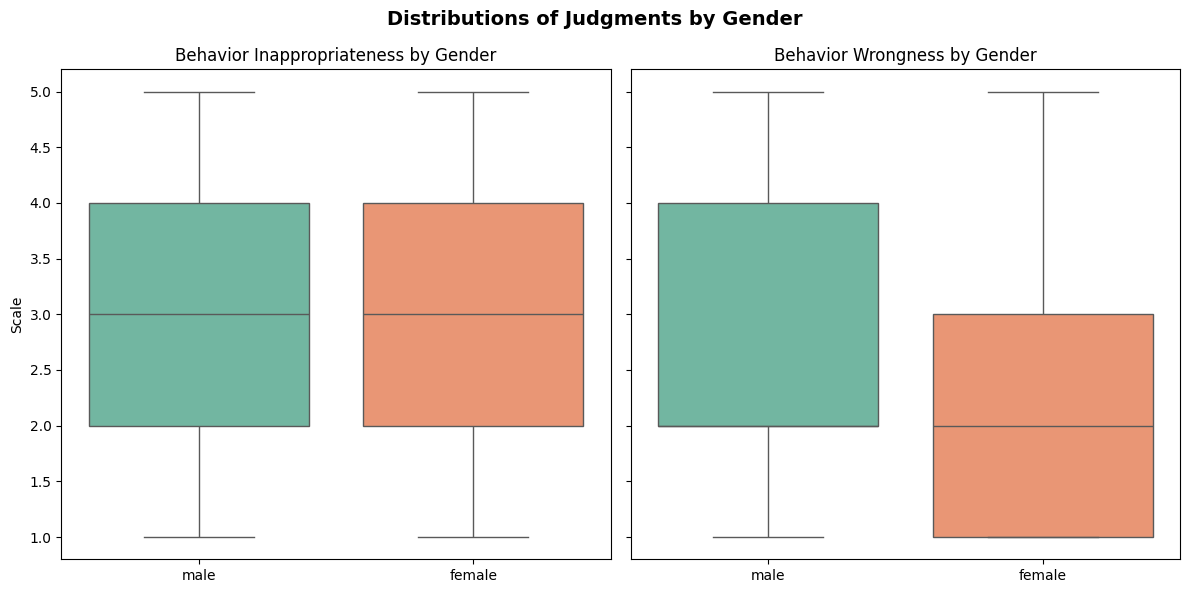

In [110]:
fig, axes = plt.subplots(1, 2, figsize=(12,6), sharey=True)

# Boxplot: Inappropriateness
sns.boxplot(
    data=df_humanness,
    x="gender", y="user_behavior_inappropriateness",
    palette="Set2", ax=axes[0]
)
axes[0].set_title("Behavior Inappropriateness by Gender")
axes[0].set_xlabel("")
axes[0].set_ylabel("Scale")

# Boxplot: Wrongness
sns.boxplot(
    data=df_humanness,
    x="gender", y="user_behavior_wrongness",
    palette="Set2", ax=axes[1]
)
axes[1].set_title("Behavior Wrongness by Gender")
axes[1].set_xlabel("")
axes[1].set_ylabel("Wrongness")

plt.suptitle("Distributions of Judgments by Gender", fontsize=14, weight="bold")
plt.tight_layout()
plt.show()

In [109]:
print(df_humanness.groupby("gender")["user_behavior_wrongness"].describe())
print(df_humanness[df_humanness["gender"]=="men"]["user_behavior_wrongness"].unique())

        count      mean       std  min  25%  50%  75%  max
gender                                                    
female  451.0  2.514412  1.282927  1.0  1.0  2.0  3.0  5.0
male    451.0  2.674058  1.290208  1.0  2.0  2.0  4.0  5.0
[]
